In [89]:
#untuk import library
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    validation_curve,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

In [90]:
#untuk setting visualisasi
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

## EDA

In [91]:
df = pd.read_csv(
    "DataCoSupplyChainDataset.csv",
    sep=";",
    decimal=",",
    encoding="latin1"
)

df.rename(columns=lambda x: x.replace("ï»¿", ""), inplace=True)
df.shape

(180519, 53)

In [92]:
df.shape
print("Jumlah data: ", df.shape)

Jumlah data:  (180519, 53)


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [94]:
df.describe()


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,-84.915675,6691.379495,36221.894903,692.509764,20.664741,0.101668,90260.000000,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,21.433241,4162.918106,21045.379569,336.446807,21.800901,0.070415,52111.490959,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025986,1.000000,1.000000,19.000000,0.000000,0.000000,1.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,-98.446312,3258.500000,18057.000000,403.000000,5.400000,0.040000,45130.500000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,-76.847908,6457.000000,36140.000000,627.000000,14.000000,0.100000,90260.000000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,-66.370583,9779.000000,54144.000000,1004.000000,29.990000,0.160000,135389.500000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.263077,20757.000000,77204.000000,1363.000000,500.000000,0.250000,180519.000000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [95]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [96]:
missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': round(df.isnull().mean() * 100, 2)
})

missing[missing['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
Customer Lname,8,0.00
Customer Zipcode,3,0.00
Order Zipcode,155679,86.24
Product Description,180519,100.00


In [97]:
# Menghapus kolom dengan missing value tinggi
df.drop(columns=['Product Description', 'Order Zipcode'], inplace=True)

# Mengisi missing value
df['Customer Lname'].fillna(df['Customer Lname'].mode()[0], inplace=True)
df['Customer Zipcode'].fillna(df['Customer Zipcode'].mode()[0], inplace=True)

# Mengecek missing value setelah preprocessing
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Email                   0
Customer Fname                   0
Customer Id                      0
Customer Lname                   0
Customer Password                0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
order date (DateOrde

In [98]:
print("Modus Customer Zip code:")
print(df["Customer Zipcode"].mode())

print("\nModus Customer Lname:")
print(df["Customer Lname"].mode())

Modus Customer Zip code:
0    725.0
Name: Customer Zipcode, dtype: float64

Modus Customer Lname:
0    Smith
Name: Customer Lname, dtype: object


In [99]:
# Mengecek & menghapus data duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah data duplikat sebelum dihapus: {duplicates}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Jumlah data duplikat setelah dihapus: {df.duplicated().sum()}")
print("Shape df setelah hapus duplikat:", df.shape)

Jumlah data duplikat sebelum dihapus: 0
Jumlah data duplikat setelah dihapus: 0
Shape df setelah hapus duplikat: (180519, 51)


In [100]:
#ini data yg udh dibersihin (kolomnya sisa 51)
df.shape

(180519, 51)

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


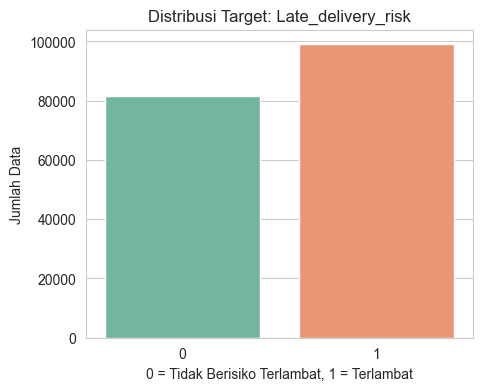

In [101]:
# Distribusi target
print(df['Late_delivery_risk'].value_counts())

print((df['Late_delivery_risk'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Late_delivery_risk', palette='Set2')
plt.title('Distribusi Target: Late_delivery_risk')
plt.xlabel('0 = Tidak Berisiko Terlambat, 1 = Terlambat')
plt.ylabel('Jumlah Data')
plt.show()

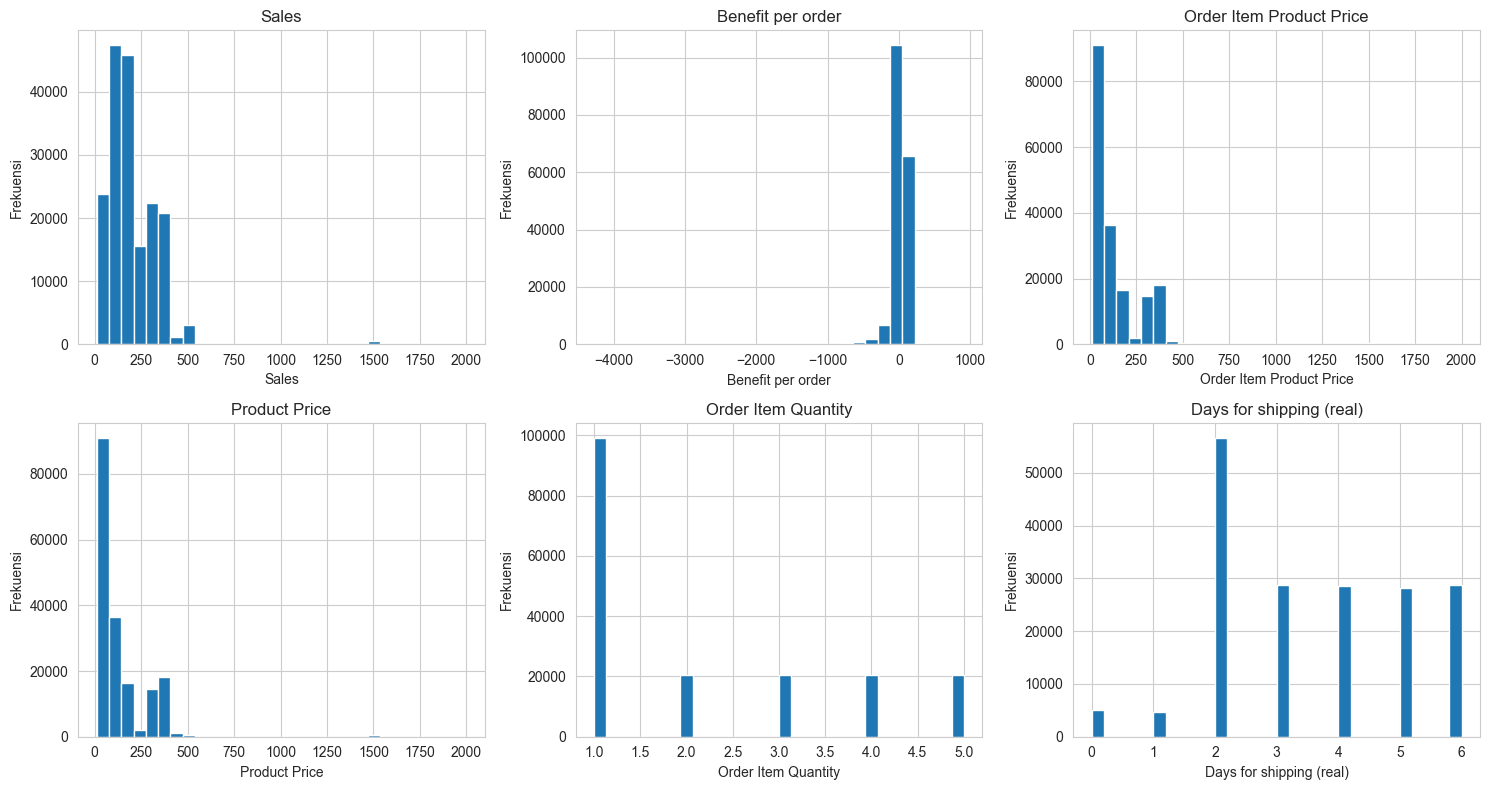

In [102]:
kolom_numerik = [
    'Sales',
    'Benefit per order',
    'Order Item Product Price',
    'Product Price',
    'Order Item Quantity',
    'Days for shipping (real)'
]

plt.figure(figsize=(15,8))

for i, col in enumerate(kolom_numerik, 1):
    plt.subplot(2,3,i)
    plt.hist(df[col], bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

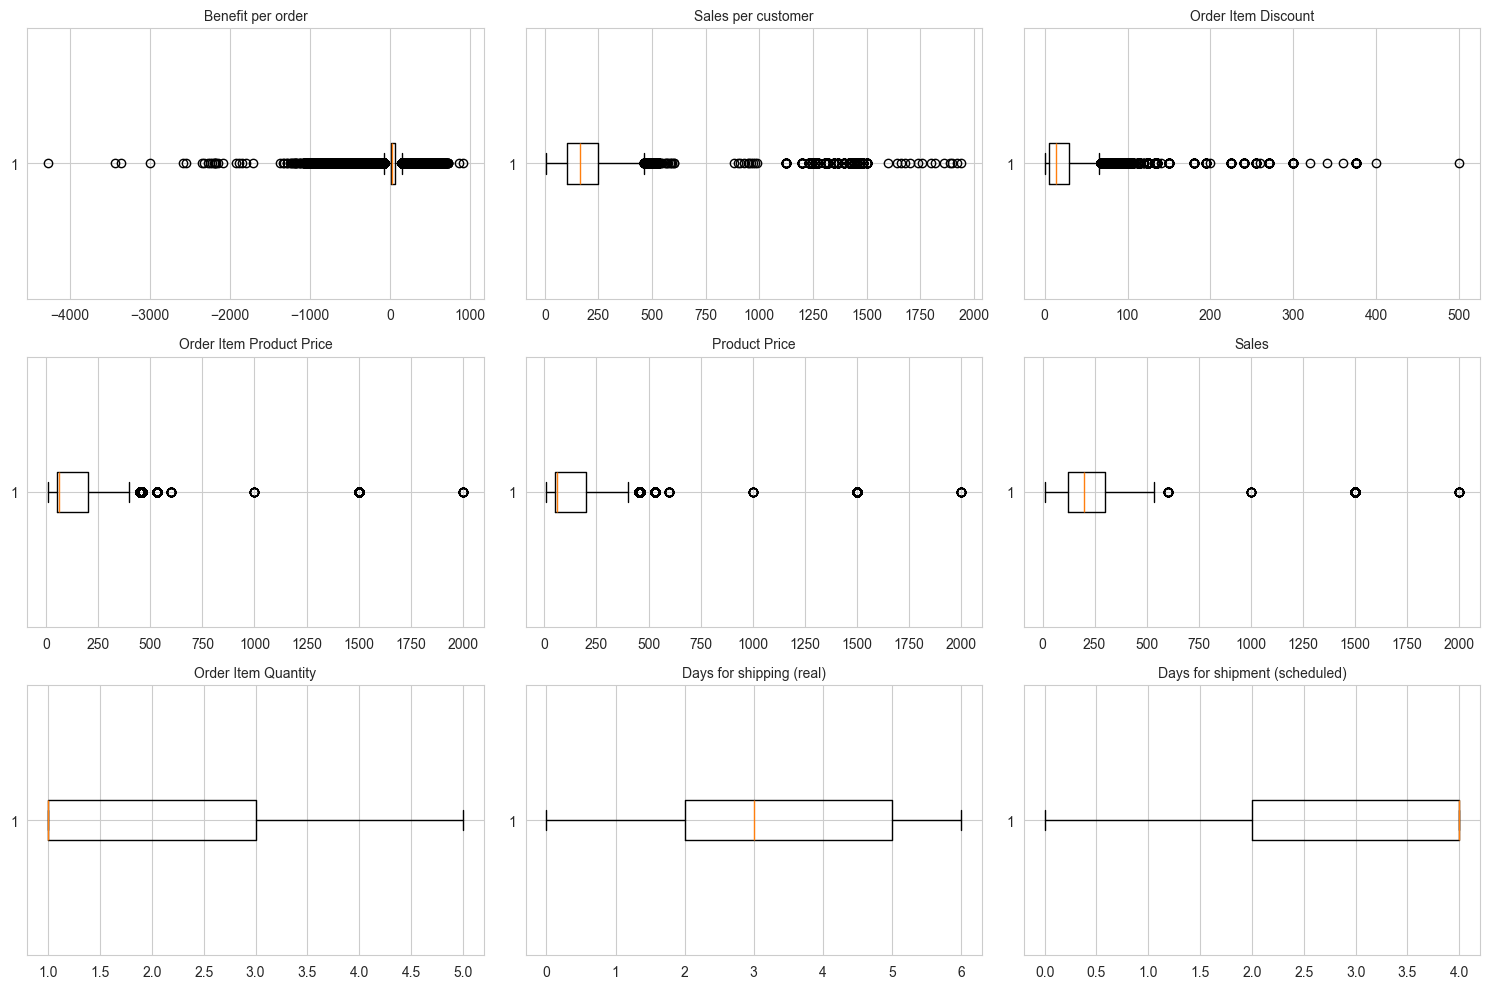

In [103]:
kolom = [
    'Benefit per order',
    'Sales per customer',
    'Order Item Discount',
    'Order Item Product Price',
    'Product Price',
    'Sales',
    'Order Item Quantity',
    'Days for shipping (real)',
    'Days for shipment (scheduled)'
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(kolom, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()

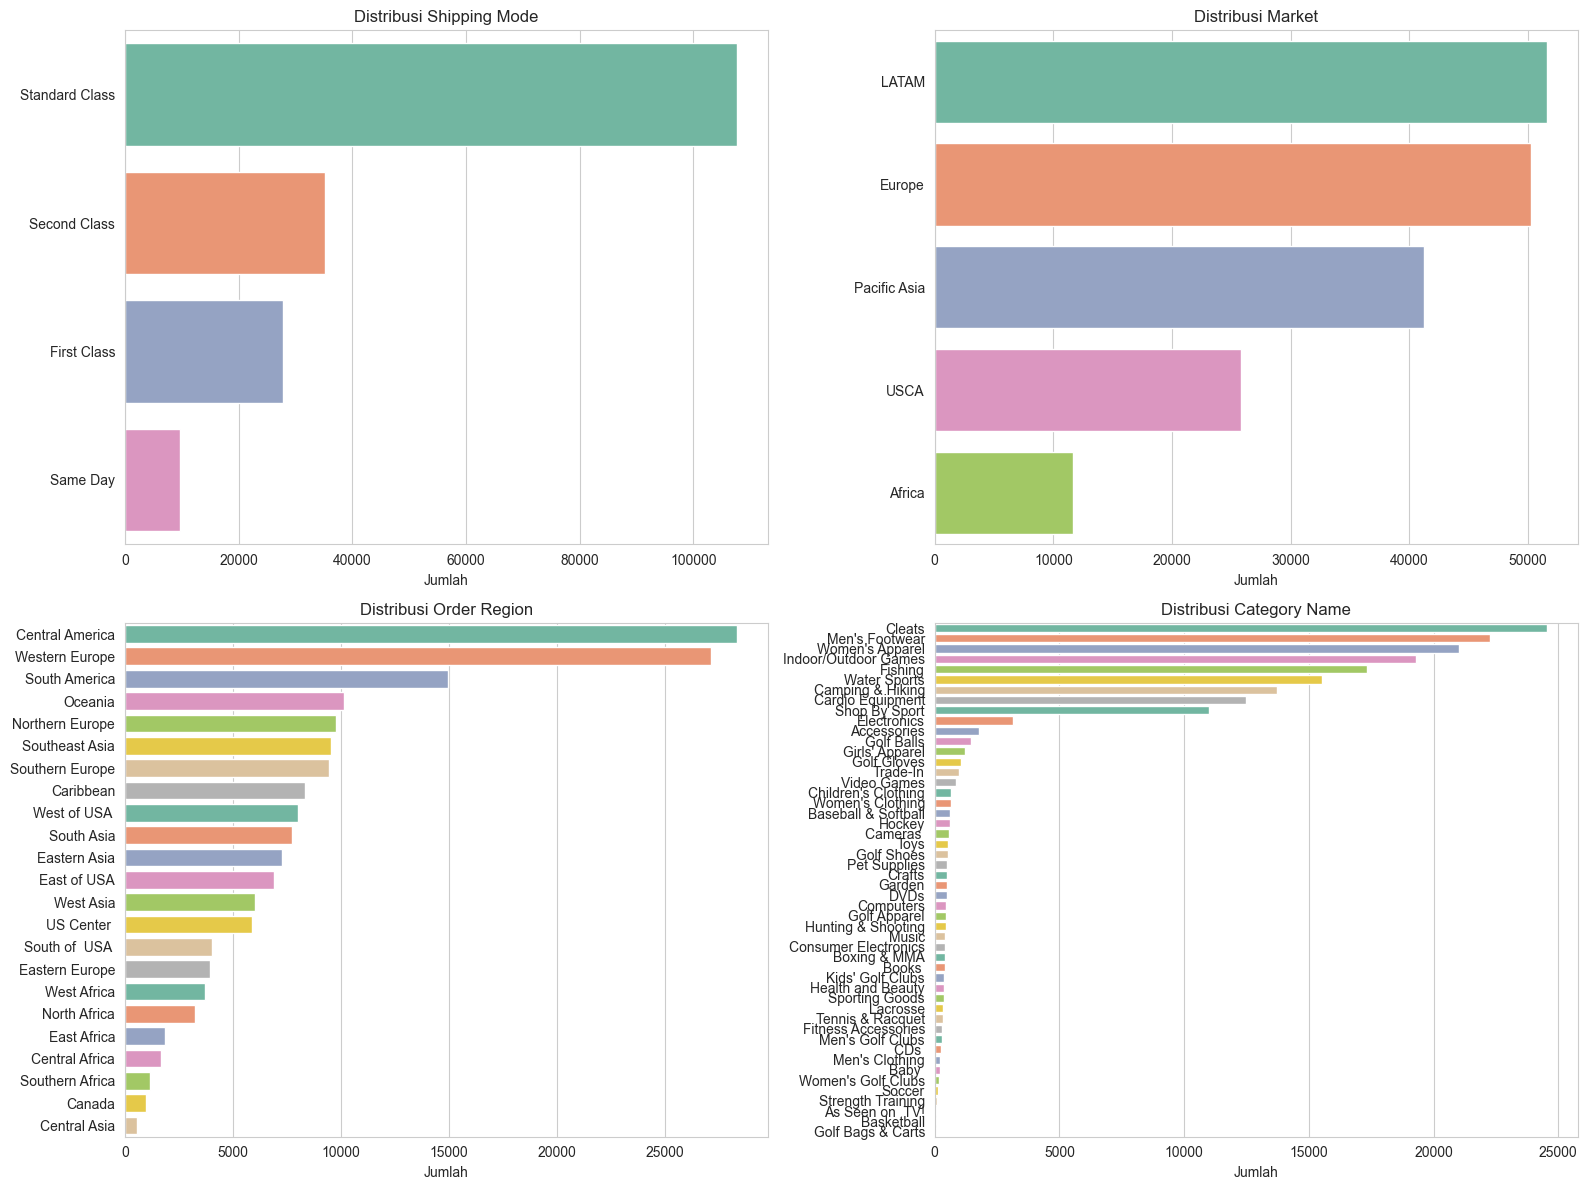

In [104]:
kolom_kategori = [
    'Shipping Mode',
    'Market',
    'Order Region',
    'Category Name'
]

plt.figure(figsize=(16,12))

for i, col in enumerate(kolom_kategori, 1):
    plt.subplot(2,2,i)

    urutan = df[col].value_counts().index

    sns.countplot(
        data=df,
        y=col,
        order=urutan,
        palette='Set2'
    )

    plt.title(f'Distribusi {col}')
    plt.xlabel('Jumlah')
    plt.ylabel('')

plt.tight_layout()
plt.show()

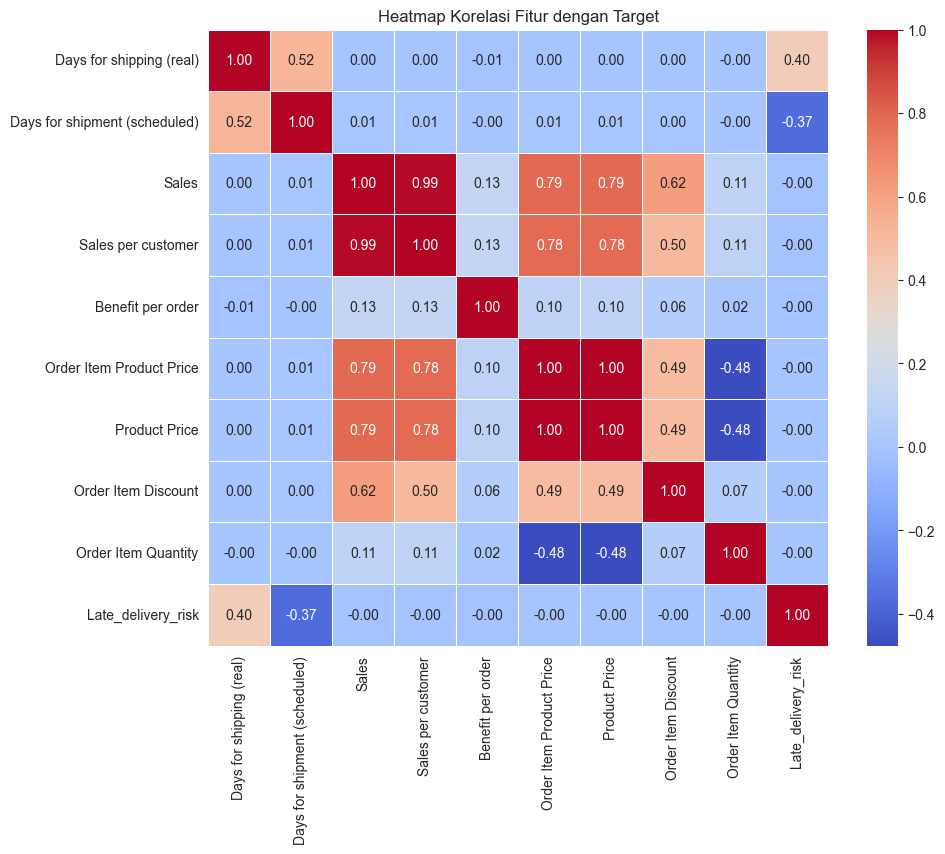

In [105]:
kolom = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Sales',
    'Sales per customer',
    'Benefit per order',
    'Order Item Product Price',
    'Product Price',
    'Order Item Discount',
    'Order Item Quantity',
    'Late_delivery_risk'   # target
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[kolom].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Heatmap Korelasi Fitur dengan Target')
plt.show()

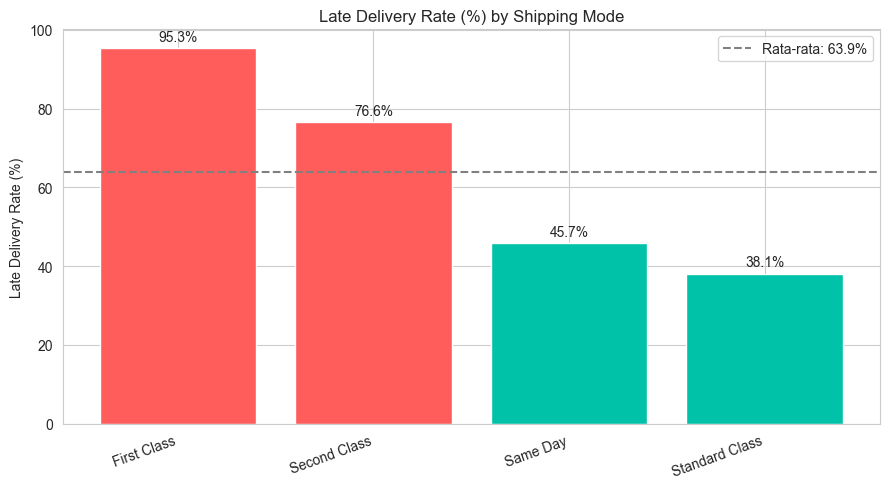

In [106]:
mode_col = df['Shipping Mode']

mode_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

# Otomatis pakai nama asli kalau kolom masih teks, atau kode angka kalau udah di-encode
if mode_col.dtype == 'object':
    labels_mode = mode_risk.index.astype(str)
else:
    labels_mode = mode_risk.index.astype(str)  # tampil sebagai kode angka saja

fig, ax = plt.subplots(figsize=(9,5))
colors = ['#FF5C5C' if v > mode_risk.mean() else '#00C2A8' for v in mode_risk]
bars = ax.bar(labels_mode, mode_risk, color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.axhline(mode_risk.mean(), ls='--', color='gray', label=f'Rata-rata: {mode_risk.mean():.1f}%')
ax.set_title('Late Delivery Rate (%) by Shipping Mode')
ax.set_ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

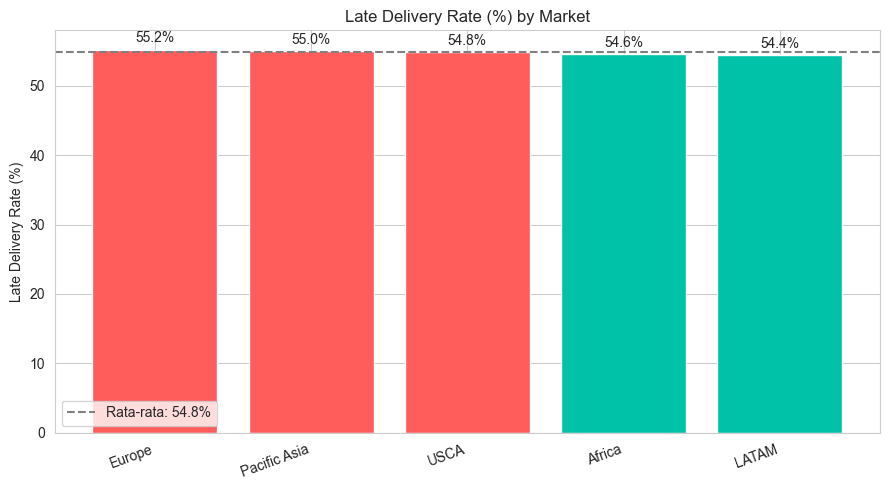

In [107]:
market_risk = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100
labels_market = market_risk.index.astype(str)

fig, ax = plt.subplots(figsize=(9,5))
colors = ['#FF5C5C' if v > market_risk.mean() else '#00C2A8' for v in market_risk]
bars = ax.bar(labels_market, market_risk, color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.axhline(market_risk.mean(), ls='--', color='gray', label=f'Rata-rata: {market_risk.mean():.1f}%')
ax.set_title('Late Delivery Rate (%) by Market')
ax.set_ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

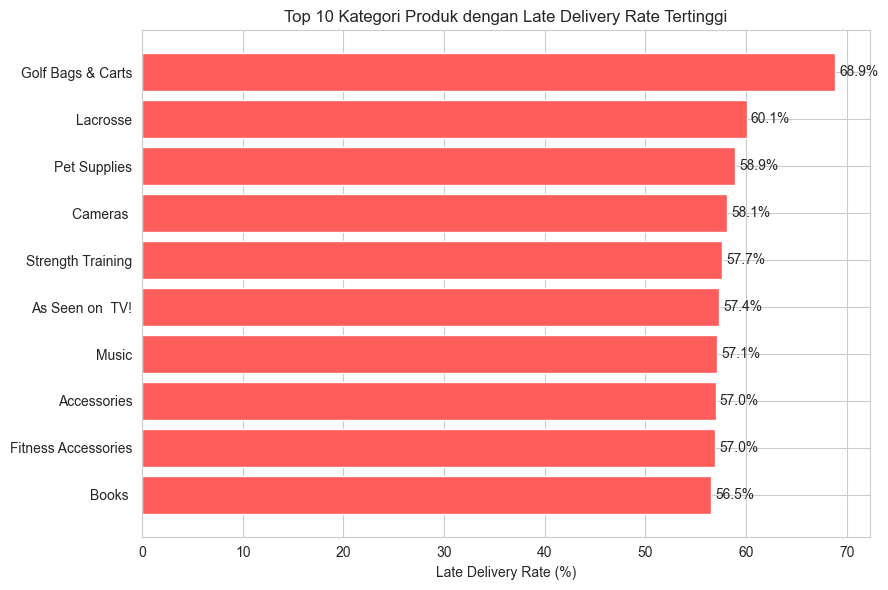

In [108]:
cat_counts = df['Category Name'].value_counts()
valid_cats = cat_counts[cat_counts >= 30].index

cat_risk = (df[df['Category Name'].isin(valid_cats)]
            .groupby('Category Name')['Late_delivery_risk']
            .mean().sort_values(ascending=False).head(10) * 100)

fig, ax = plt.subplots(figsize=(9,6))
bars = ax.barh(cat_risk.index.astype(str), cat_risk, color='#FF5C5C')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.invert_yaxis()
ax.set_title('Top 10 Kategori Produk dengan Late Delivery Rate Tertinggi')
ax.set_xlabel('Late Delivery Rate (%)')
plt.tight_layout()
plt.show()

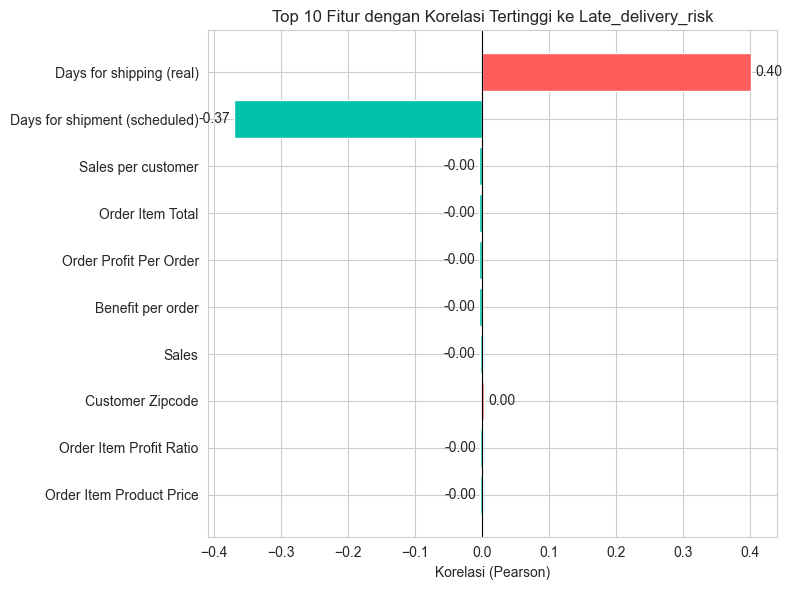

In [109]:
target_corr = (df.select_dtypes(include=np.number)
               .corr()['Late_delivery_risk']
               .drop('Late_delivery_risk'))
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(10)

fig, ax = plt.subplots(figsize=(8,6))
colors = ['#FF5C5C' if v > 0 else '#00C2A8' for v in target_corr]
bars = ax.barh(target_corr.index, target_corr, color=colors)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Fitur dengan Korelasi Tertinggi ke Late_delivery_risk')
ax.set_xlabel('Korelasi (Pearson)')
plt.tight_layout()
plt.show()

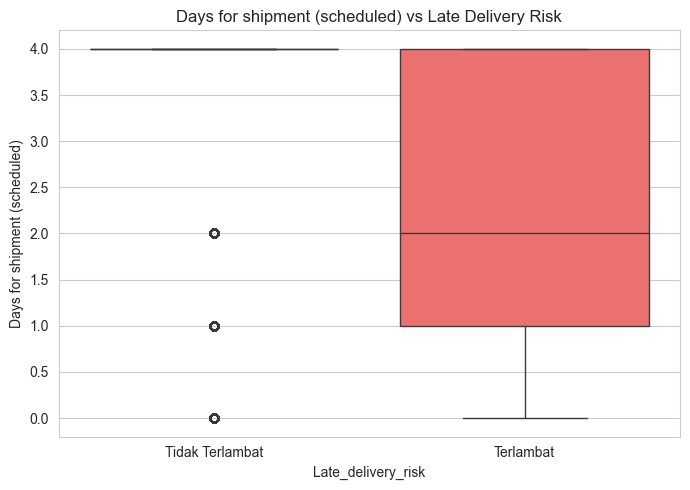

In [110]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x='Late_delivery_risk', y='Days for shipment (scheduled)',
            palette=['#00C2A8', '#FF5C5C'], ax=ax)
ax.set_xticklabels(['Tidak Terlambat', 'Terlambat'])
ax.set_title('Days for shipment (scheduled) vs Late Delivery Risk')
plt.tight_layout()
plt.show()

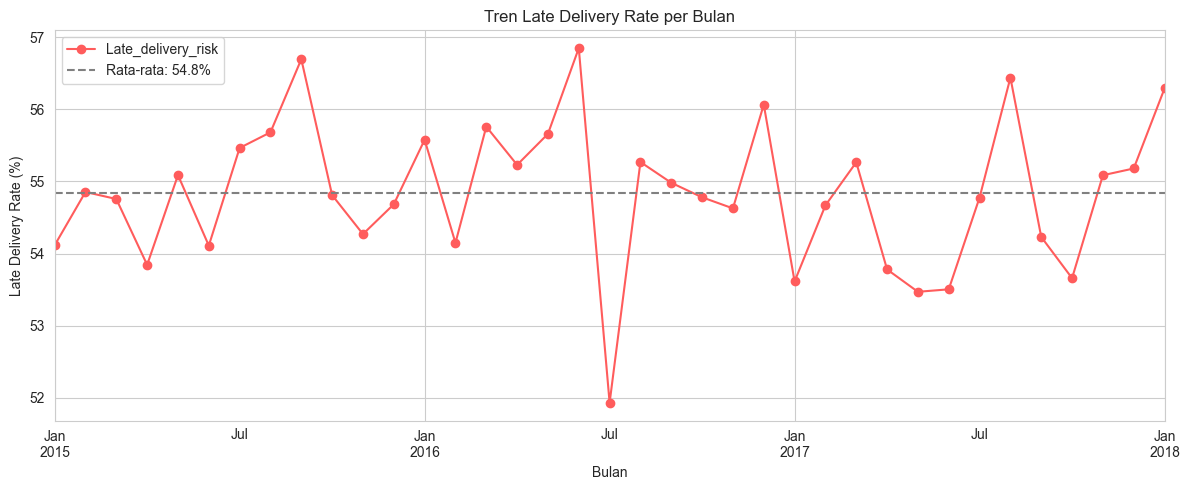

In [111]:
df_time = df.copy()
df_time['order_month'] = pd.to_datetime(df_time['order date (DateOrders)']).dt.to_period('M')

monthly_risk = df_time.groupby('order_month')['Late_delivery_risk'].mean() * 100

fig, ax = plt.subplots(figsize=(12,5))
monthly_risk.plot(ax=ax, marker='o', color='#FF5C5C')
ax.axhline(monthly_risk.mean(), ls='--', color='gray', label=f'Rata-rata: {monthly_risk.mean():.1f}%')
ax.set_title('Tren Late Delivery Rate per Bulan')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_xlabel('Bulan')
ax.legend()
plt.tight_layout()
plt.show()

## Data Preprocessing

In [112]:
# Menghapus fitur identitas, ID yang tidak diperlukan, dan fitur yang redundant
df.drop(columns=[
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Id',
    'Order Customer Id',
    'Order Id',
    'Order Item Id',
    'Order Item Cardprod Id',
    'Product Card Id',
    'Product Image',
    'Product Status',
    'Category Id',
    'Department Id',
    'Product Price',
    'Order Profit Per Order',
    'order date (DateOrders)',
    'shipping date (DateOrders)',
    'Days for shipping (real)',
    'Delivery Status',
], inplace=True)

print(f"Jumlah kolom setelah preprocessing: {df.shape[1]}")
df.info()

Jumlah kolom setelah preprocessing: 30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipment (scheduled)  180519 non-null  int64  
 2   Benefit per order              180519 non-null  float64
 3   Sales per customer             180519 non-null  float64
 4   Late_delivery_risk             180519 non-null  int64  
 5   Category Name                  180519 non-null  object 
 6   Customer City                  180519 non-null  object 
 7   Customer Country               180519 non-null  object 
 8   Customer Segment               180519 non-null  object 
 9   Customer State                 180519 non-null  object 
 10  Customer Zipcode               180519 non-null  float64
 11  Department Name                180519 non-null  obje

In [113]:
#encoding ubah kategorikal/object jd numerik
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

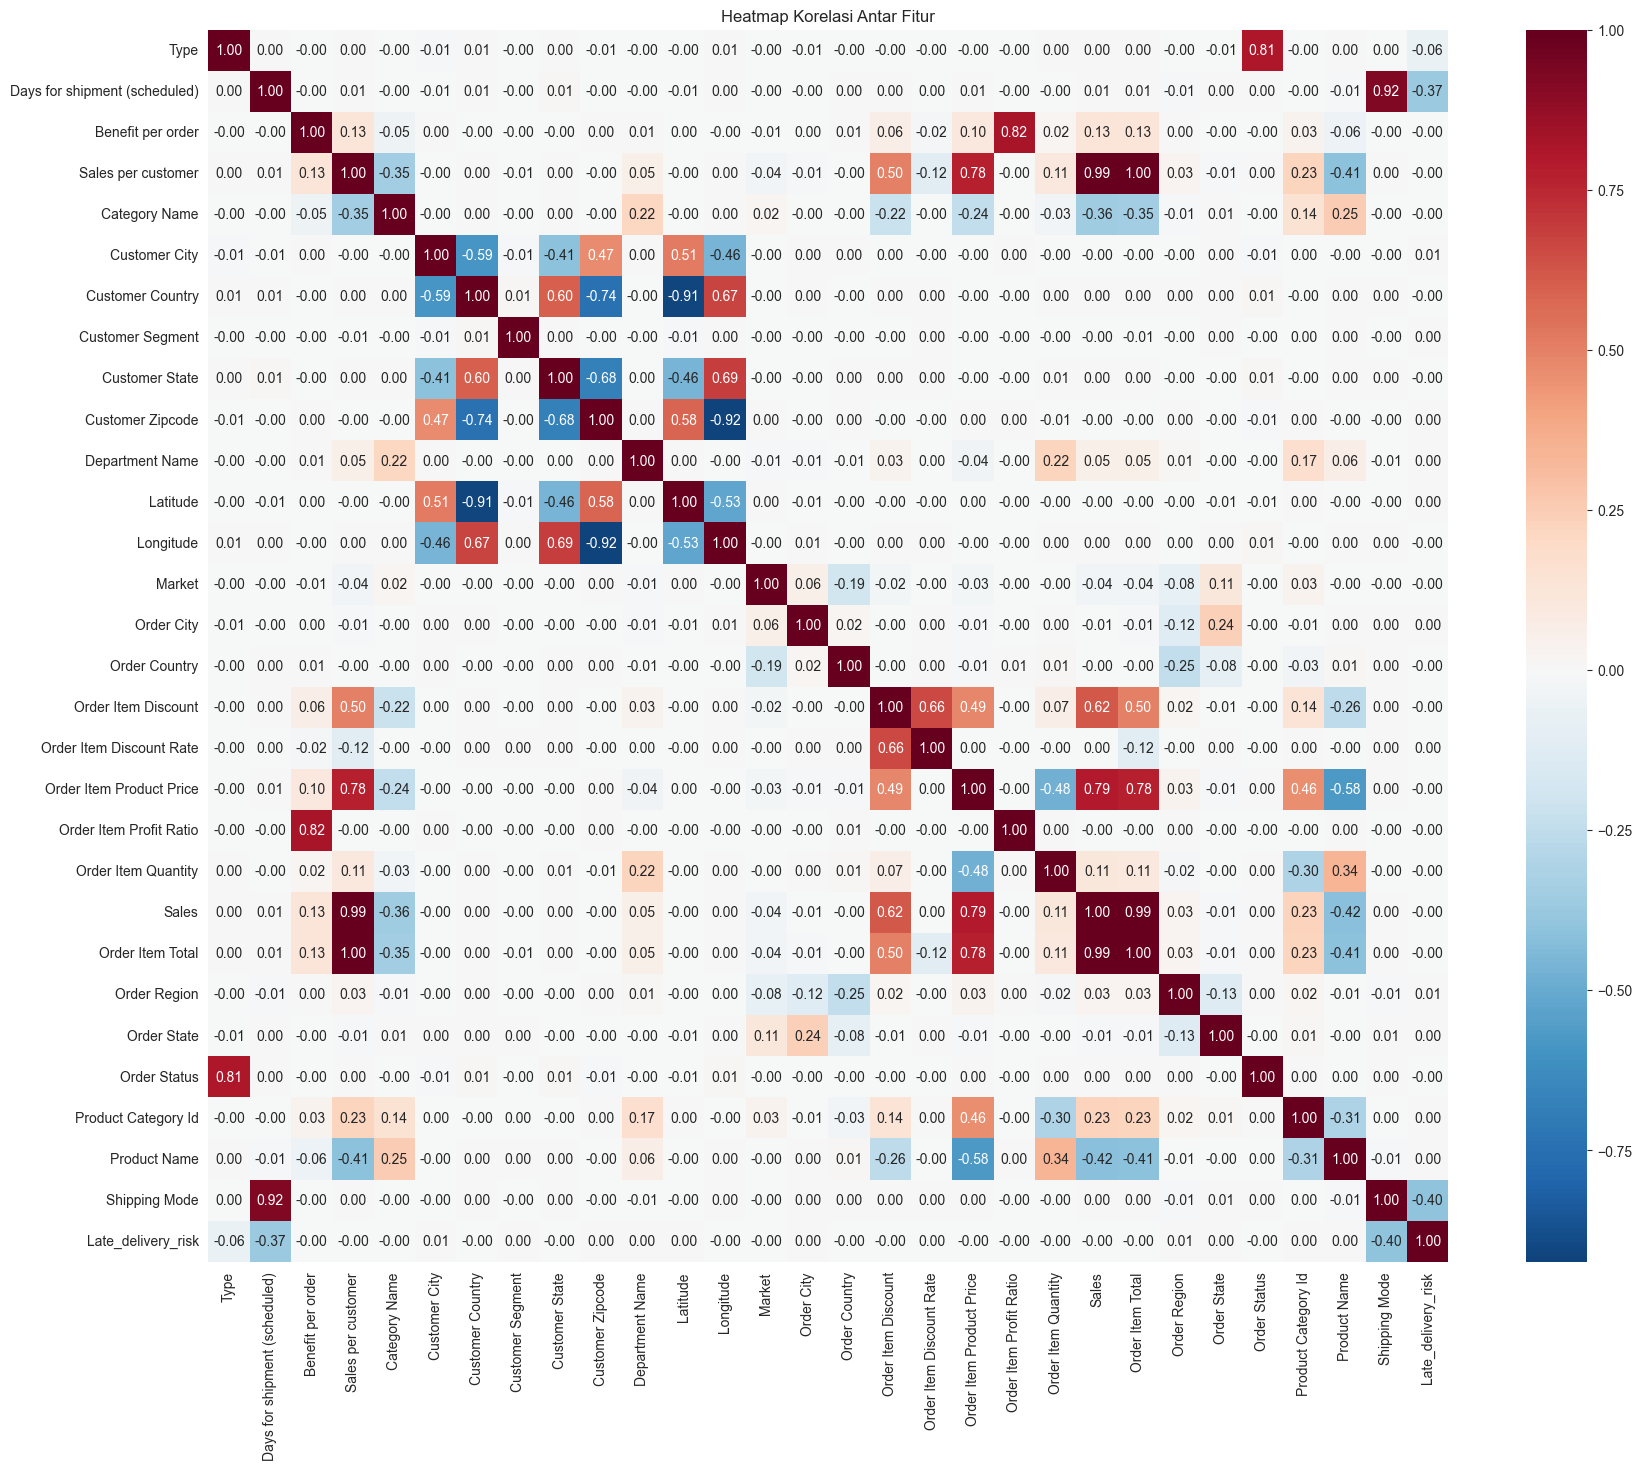

In [114]:
target = "Late_delivery_risk"

cols = [c for c in df.columns if c != target] + [target]
df = df[cols]
plt.figure(figsize=(20,16))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

In [115]:
mapping = pd.DataFrame({
    "Kategori Asli": label_encoders["Type"].classes_,
    "Hasil Encoding": range(len(label_encoders["Type"].classes_))
})

print(mapping)

  Kategori Asli  Hasil Encoding
0          CASH               0
1         DEBIT               1
2       PAYMENT               2
3      TRANSFER               3


### Feature Engineering

In [116]:
# fitur baru: Total_Item_Value (harga x qty) & High_Discount_Flag (diskon di atas rata2 apa enggak)
#'Days for shipping (real)' gapake krn udh didrop dari awal - itu langsung nentuin telat/egknya (leakage kalo dipake)

df['Total_Item_Value'] = df['Order Item Product Price'] * df['Order Item Quantity']
df['High_Discount_Flag'] = (df['Order Item Discount Rate'] > df['Order Item Discount Rate'].median()).astype(int)

print("Fitur baru berhasil dibuat: 'Total_Item_Value' dan 'High_Discount_Flag'")
df[['Order Item Product Price', 'Order Item Quantity', 'Total_Item_Value',
    'Order Item Discount Rate', 'High_Discount_Flag']].head(10)

Fitur baru berhasil dibuat: 'Total_Item_Value' dan 'High_Discount_Flag'


,Order Item Product Price,Order Item Quantity,Total_Item_Value,Order Item Discount Rate,High_Discount_Flag
0,327.75,1,327.75,0.04,0
1,327.75,1,327.75,0.05,0
2,327.75,1,327.75,0.06,0
3,327.75,1,327.75,0.07,0
4,327.75,1,327.75,0.09,0
5,327.75,1,327.75,0.10,0
6,327.75,1,327.75,0.12,1
7,327.75,1,327.75,0.13,1
8,327.75,1,327.75,0.15,1
9,327.75,1,327.75,0.16,1


(40000, 32)
Late_delivery_risk
1    21932
0    18068
Name: count, dtype: int64
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


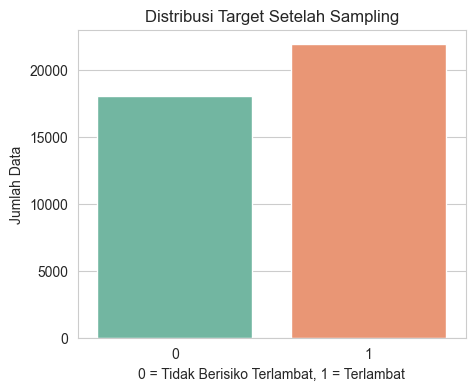

(40000, 31)
31
Jumlah data training: (32000, 31)
Jumlah data testing : (8000, 31)


In [117]:
# Split data

SAMPLE_SIZE = 40000

# 1. Sampling 40rb data
if len(df) > SAMPLE_SIZE:
    df, _ = train_test_split(
        df,
        train_size=SAMPLE_SIZE,
        stratify=df["Late_delivery_risk"],
        random_state=42
    )

print(df.shape)

print(df["Late_delivery_risk"].value_counts())

print((df["Late_delivery_risk"].value_counts(normalize=True) * 100).round(2))

# Grafik distribusi target
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Late_delivery_risk', palette='Set2')
plt.title('Distribusi Target Setelah Sampling')
plt.xlabel('0 = Tidak Berisiko Terlambat, 1 = Terlambat')
plt.ylabel('Jumlah Data')
plt.show()

# 2. Untuk membuat fitur dan target
X = df.drop("Late_delivery_risk", axis=1)
y = df["Late_delivery_risk"]

print(X.shape)
print(len(X.columns))

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Jumlah data training:", X_train.shape)
print("Jumlah data testing :", X_test.shape)

### Feature Selection

In [118]:
# Feature Selection: fit HANYA pada data training untuk menghindari data leakage,
# baru diterapkan (transform) ke data training & testing dengan fitur yang sama

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

results = []

for k in [10, 15, 17, 20, 30, 31]:

    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_fs = selector.fit_transform(X_train, y_train)
    X_test_fs = selector.transform(X_test)

    model = XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train_fs, y_train)

    y_prob = model.predict_proba(X_test_fs)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    results.append((k, auc))

for k, auc in results:
    print(f"k = {k:2d} | ROC-AUC = {auc:.4f}")

k = 10 | ROC-AUC = 0.7692
k = 15 | ROC-AUC = 0.7909
k = 17 | ROC-AUC = 0.7921
k = 20 | ROC-AUC = 0.7851
k = 30 | ROC-AUC = 0.7957
k = 31 | ROC-AUC = 0.7957


In [119]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]
feature_table = pd.DataFrame({
    "No": range(1, len(selected_features) + 1),
    "Selected Feature": selected_features
})
display(feature_table)


X_train = X_train[selected_features]
X_test = X_test[selected_features]

print(f"\nShape X_train : {X_train.shape}")
print(f"Shape X_test  : {X_test.shape}")

,No,Selected Feature
0,1,Type
1,2,Days for shipment (scheduled)
2,3,Customer State
3,4,Department Name
4,5,Longitude
5,6,Order City
6,7,Order Country
7,8,Order Item Discount
8,9,Order Item Product Price
9,10,Order Item Quantity



Shape X_train : (32000, 15)
Shape X_test  : (8000, 15)


## ALGORITMA LOGISTIC REGRESSION

In [120]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [121]:
# ==========================================
# BASELINE LOGISTIC REGRESSION
# ==========================================

lr_base = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_base.fit(X_train_scaled, y_train)

y_pred_lr_base = lr_base.predict(X_test_scaled)
y_prob_lr_base = lr_base.predict_proba(X_test_scaled)[:, 1]

print("=== Baseline Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr_base))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr_base))
print(classification_report(y_test, y_pred_lr_base))

=== Baseline Logistic Regression ===
Accuracy : 0.69675
ROC-AUC  : 0.73235657501569
              precision    recall  f1-score   support

           0       0.62      0.84      0.72      3614
           1       0.82      0.58      0.68      4386

    accuracy                           0.70      8000
   macro avg       0.72      0.71      0.70      8000
weighted avg       0.73      0.70      0.69      8000



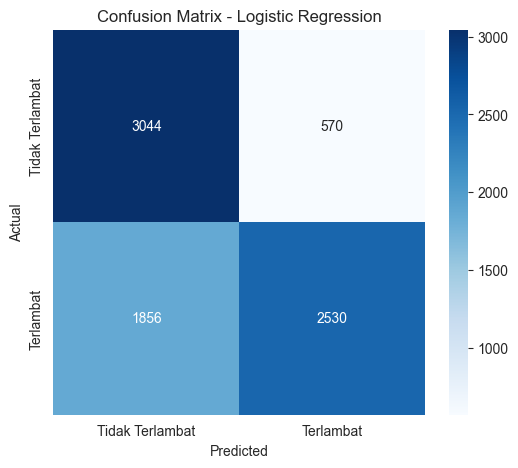

In [122]:
cm = confusion_matrix(y_test, y_pred_lr_base)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Terlambat', 'Terlambat'],
    yticklabels=['Tidak Terlambat', 'Terlambat']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [123]:
train_acc = accuracy_score(y_train, lr_base.predict(X_train_scaled)) * 100
test_acc = accuracy_score(y_test, lr_base.predict(X_test_scaled)) * 100

print(f"Training Accuracy : {train_acc:.2f}%")
print(f"Testing Accuracy  : {test_acc:.2f}%")
print(f"Gap               : {train_acc - test_acc:.2f}%")

Training Accuracy : 69.12%
Testing Accuracy  : 69.67%
Gap               : -0.56%


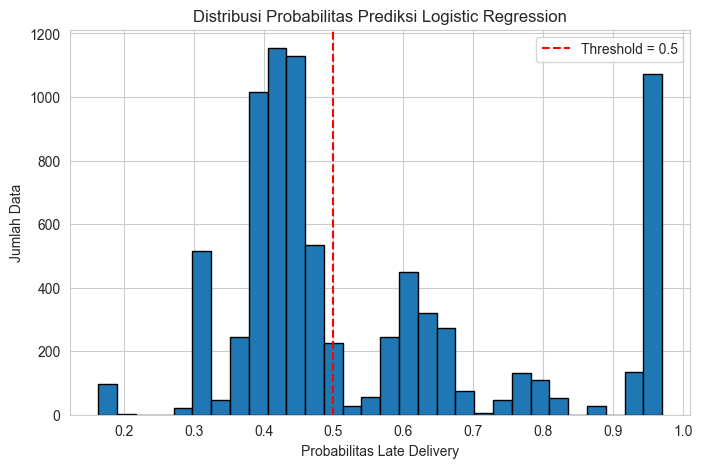

In [124]:
# Probabilitas kelas 1 (Late Delivery)
y_prob = lr_base.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(8,5))
plt.hist(y_prob, bins=30, edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')

plt.title('Distribusi Probabilitas Prediksi Logistic Regression')
plt.xlabel('Probabilitas Late Delivery')
plt.ylabel('Jumlah Data')
plt.legend()
plt.show()

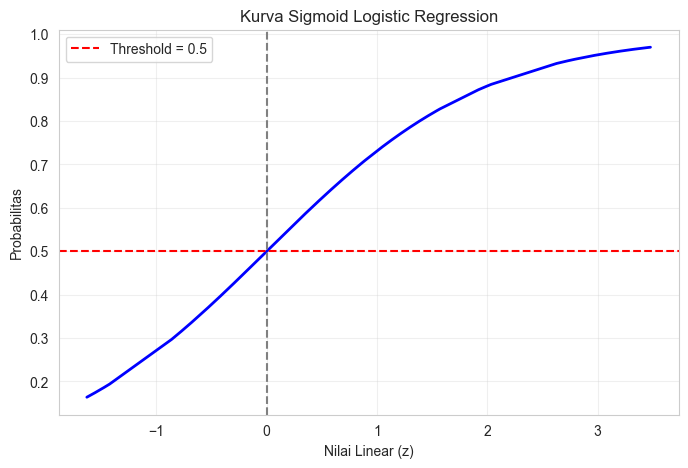

In [125]:
# Nilai linear (z) dari model
z = lr_base.decision_function(X_test_scaled)

# Probabilitas hasil model
prob = lr_base.predict_proba(X_test_scaled)[:, 1]

# Urutkan agar membentuk kurva
idx = np.argsort(z)
z_sorted = z[idx]
prob_sorted = prob[idx]

plt.figure(figsize=(8,5))
plt.plot(z_sorted, prob_sorted, color='blue', linewidth=2)

plt.axhline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.axvline(0, color='gray', linestyle='--')

plt.xlabel('Nilai Linear (z)')
plt.ylabel('Probabilitas')
plt.title('Kurva Sigmoid Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [126]:
param_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs'],
    'penalty': ['l2'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print("LR - Best Parameter:", grid_lr.best_params_)
print("LR - Best ROC-AUC  :", grid_lr.best_score_)

LR - Best Parameter: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
LR - Best ROC-AUC  : 0.7280750092809913


In [127]:
lr = grid_lr.best_estimator_

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))


Accuracy : 0.6895

Classification Report
              precision    recall  f1-score   support

           0       0.61      0.85      0.71      3614
           1       0.82      0.56      0.66      4386

    accuracy                           0.69      8000
   macro avg       0.72      0.70      0.69      8000
weighted avg       0.73      0.69      0.69      8000



In [128]:
train_acc = accuracy_score(y_train, lr.predict(X_train_scaled)) * 100
test_acc = accuracy_score(y_test, lr.predict(X_test_scaled)) * 100

print(f"Training Accuracy : {train_acc:.2f}%")
print(f"Testing Accuracy  : {test_acc:.2f}%")
print(f"Gap               : {train_acc - test_acc:.2f}%")

Training Accuracy : 68.36%
Testing Accuracy  : 68.95%
Gap               : -0.59%


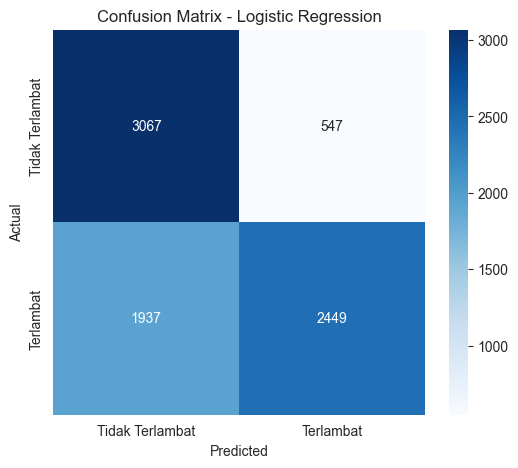

In [129]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Terlambat', 'Terlambat'],
    yticklabels=['Tidak Terlambat', 'Terlambat']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

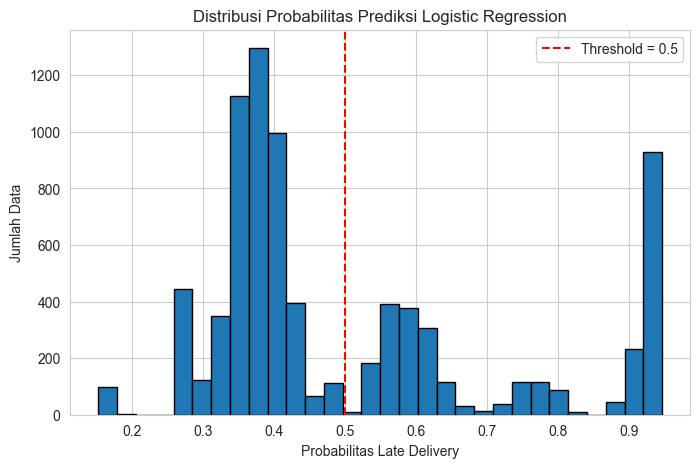

In [130]:


# Probabilitas kelas 1 (Late Delivery)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(8,5))
plt.hist(y_prob, bins=30, edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')

plt.title('Distribusi Probabilitas Prediksi Logistic Regression')
plt.xlabel('Probabilitas Late Delivery')
plt.ylabel('Jumlah Data')
plt.legend()
plt.show()

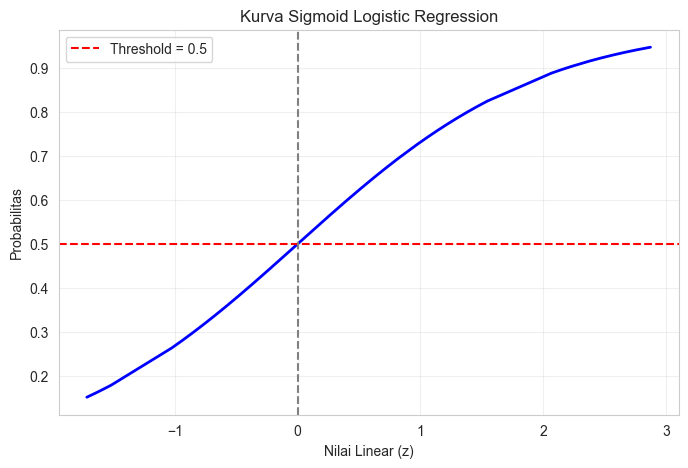

In [131]:
# Nilai linear (z) dari model
z = lr.decision_function(X_test_scaled)

# Probabilitas hasil model
prob = lr.predict_proba(X_test_scaled)[:, 1]

# Urutkan agar membentuk kurva
idx = np.argsort(z)
z_sorted = z[idx]
prob_sorted = prob[idx]

plt.figure(figsize=(8,5))
plt.plot(z_sorted, prob_sorted, color='blue', linewidth=2)

plt.axhline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.axvline(0, color='gray', linestyle='--')

plt.xlabel('Nilai Linear (z)')
plt.ylabel('Probabilitas')
plt.title('Kurva Sigmoid Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [132]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

## ALGORITMA RANDOM FOREST

In [133]:
# ==========================
# BASELINE RANDOM FOREST
# ==========================

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

y_pred_rf_base = rf_base.predict(X_test)
y_prob_rf_base = rf_base.predict_proba(X_test)[:, 1]

print("=== Baseline Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf_base))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf_base))
print(classification_report(y_test, y_pred_rf_base))

=== Baseline Random Forest ===
Accuracy : 0.712375
ROC-AUC  : 0.7969829545182122
              precision    recall  f1-score   support

           0       0.65      0.78      0.71      3614
           1       0.79      0.65      0.71      4386

    accuracy                           0.71      8000
   macro avg       0.72      0.72      0.71      8000
weighted avg       0.73      0.71      0.71      8000



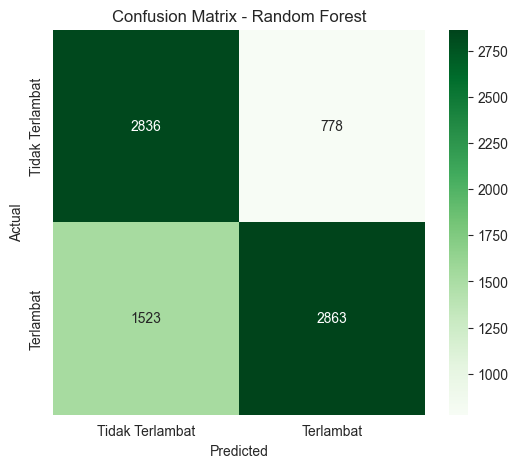

In [134]:
cm = confusion_matrix(y_test, y_pred_rf_base)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Tidak Terlambat', 'Terlambat'],
    yticklabels=['Tidak Terlambat', 'Terlambat']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [135]:
train_pred = rf_base.predict(X_train)

train_acc = accuracy_score(y_train, train_pred) * 100
test_acc = accuracy_score(y_test, y_pred_rf_base) * 100

print(f"Training Accuracy : {train_acc:.2f}%")
print(f"Testing Accuracy  : {test_acc:.2f}%")
print(f"Gap               : {train_acc - test_acc:.2f}%")

Training Accuracy : 100.00%
Testing Accuracy  : 71.24%
Gap               : 28.76%


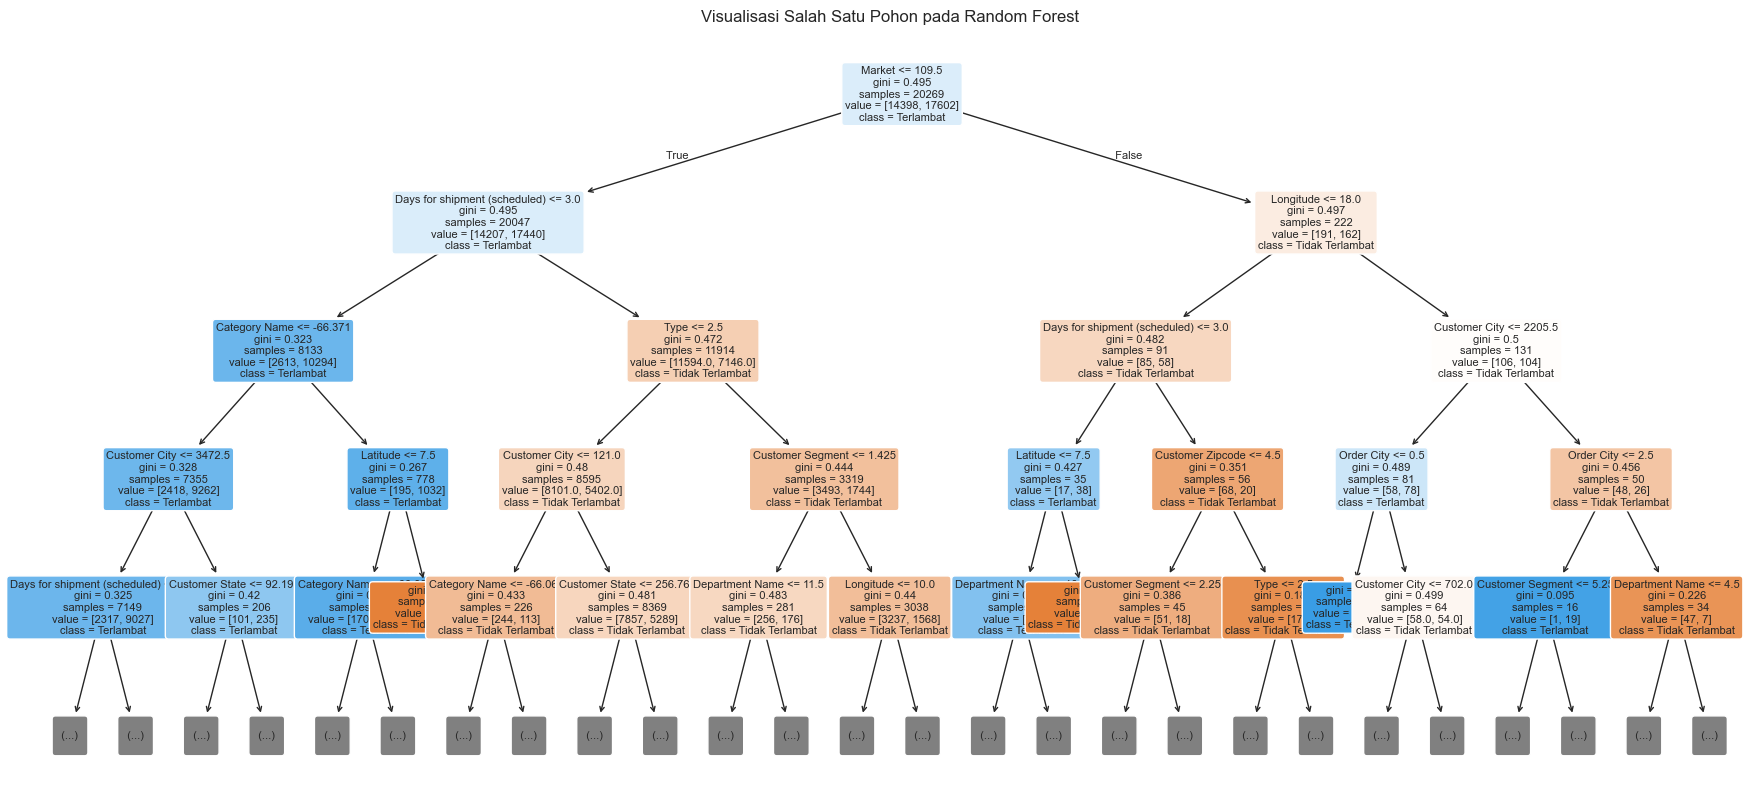

In [136]:
#visualisasi rf
from sklearn.tree import plot_tree
plt.figure(figsize=(22, 10))

plot_tree(
    rf_base.estimators_[0],      
    feature_names=X.columns,
    class_names=["Tidak Terlambat", "Terlambat"],
    filled=True,
    rounded=True,
    max_depth=4,            
    fontsize=8
)

plt.title("Visualisasi Salah Satu Pohon pada Random Forest")
plt.show()

In [137]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, 16],
    'min_samples_split': [20, 40, 60],
    'min_samples_leaf': [10, 20, 30]
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_rf,
    n_iter=15, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42
)
random_rf.fit(X_train, y_train)

print("RF - Best Parameter:", random_rf.best_params_)
print("RF - Best ROC-AUC  :", random_rf.best_score_)

rf = random_rf.best_estimator_   

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF - Best Parameter: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_depth': 12}
RF - Best ROC-AUC  : 0.7755712644026638
Accuracy : 0.71625
              precision    recall  f1-score   support

           0       0.63      0.90      0.74      3614
           1       0.87      0.57      0.69      4386

    accuracy                           0.72      8000
   macro avg       0.75      0.73      0.71      8000
weighted avg       0.76      0.72      0.71      8000



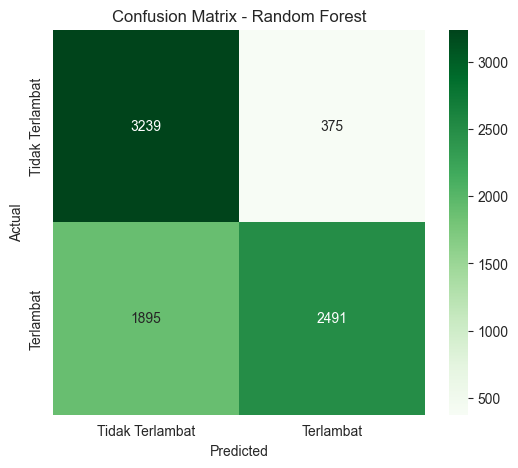

In [138]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Tidak Terlambat', 'Terlambat'],
    yticklabels=['Tidak Terlambat', 'Terlambat']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [139]:
train_pred = rf.predict(X_train)

train_acc = accuracy_score(y_train, train_pred) * 100
test_acc = accuracy_score(y_test, y_pred_rf) * 100

print(f"Training Accuracy : {train_acc:.2f}%")
print(f"Testing Accuracy  : {test_acc:.2f}%")
print(f"Gap               : {train_acc - test_acc:.2f}%")

Training Accuracy : 72.90%
Testing Accuracy  : 71.62%
Gap               : 1.27%


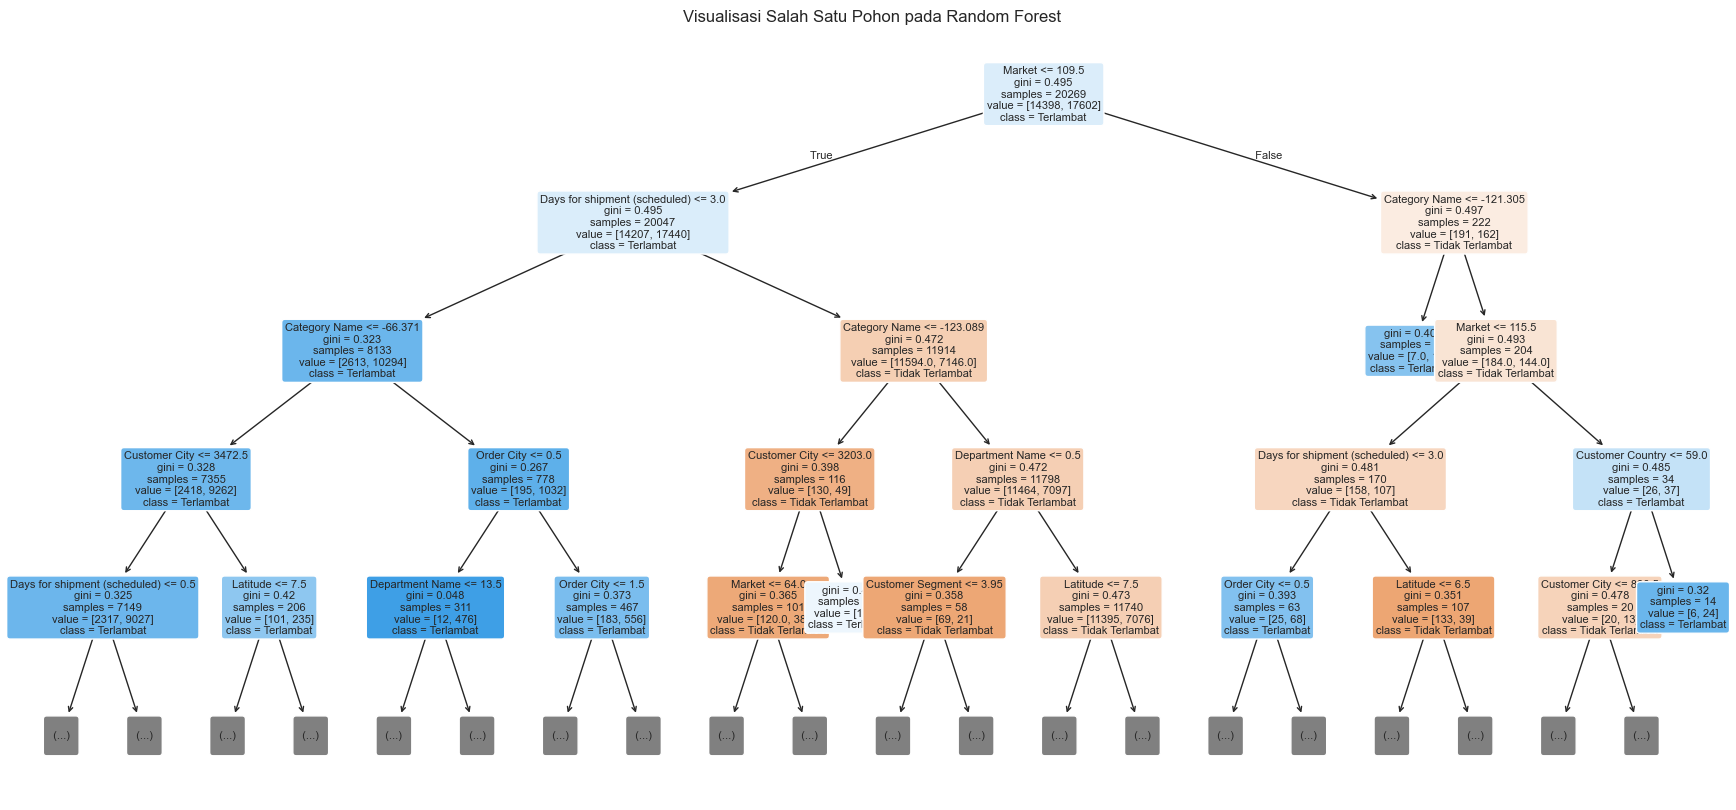

In [140]:
#visualisasi rf
from sklearn.tree import plot_tree
plt.figure(figsize=(22, 10))

plot_tree(
    rf.estimators_[0],      
    feature_names=X.columns,
    class_names=["Tidak Terlambat", "Terlambat"],
    filled=True,
    rounded=True,
    max_depth=4,            
    fontsize=8
)

plt.title("Visualisasi Salah Satu Pohon pada Random Forest")
plt.show()

## ALGORITMA XGBoost

In [141]:
# ==========================================
# BASELINE XGBOOST
# ==========================================

from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_base.fit(X_train, y_train)

y_pred_xgb_base = xgb_base.predict(X_test)
y_prob_xgb_base = xgb_base.predict_proba(X_test)[:, 1]

print("=== Baseline XGBoost ===")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_base))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb_base))
print(classification_report(y_test, y_pred_xgb_base))

=== Baseline XGBoost ===
Accuracy : 0.7135
ROC-AUC  : 0.7909016047185403
              precision    recall  f1-score   support

           0       0.65      0.79      0.71      3614
           1       0.79      0.65      0.71      4386

    accuracy                           0.71      8000
   macro avg       0.72      0.72      0.71      8000
weighted avg       0.73      0.71      0.71      8000



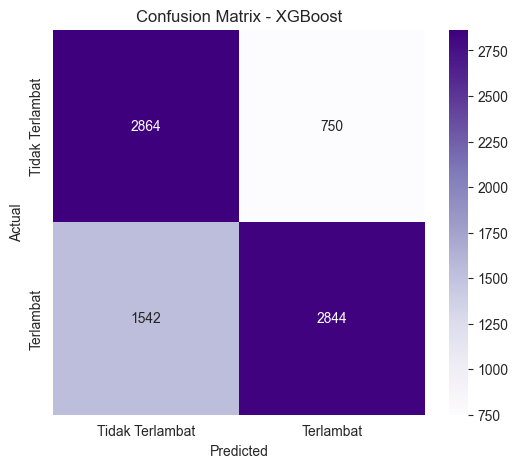

In [142]:
cm = confusion_matrix(y_test, y_pred_xgb_base)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Tidak Terlambat', 'Terlambat'],
    yticklabels=['Tidak Terlambat', 'Terlambat']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [143]:
train_pred = xgb_base.predict(X_train)

train_acc = accuracy_score(y_train, train_pred) * 100
test_acc = accuracy_score(y_test, y_pred_xgb_base) * 100

print(f"Training Accuracy : {train_acc:.2f}%")
print(f"Testing Accuracy  : {test_acc:.2f}%")
print(f"Gap               : {train_acc - test_acc:.2f}%")

Training Accuracy : 80.40%
Testing Accuracy  : 71.35%
Gap               : 9.05%


In [144]:
from xgboost import XGBClassifier

param_xgb = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_child_weight': [5, 7, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 3, 5]
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_distributions=param_xgb,
    n_iter=50   , cv=5, scoring='roc_auc', n_jobs=-1, random_state=42
)
random_xgb.fit(X_train, y_train)

print("XGB - Best Parameter:", random_xgb.best_params_)
print("XGB - Best ROC-AUC  :", random_xgb.best_score_)

xgb = random_xgb.best_estimator_

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB - Best Parameter: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}
XGB - Best ROC-AUC  : 0.781463669144663
Accuracy : 0.714875
              precision    recall  f1-score   support

           0       0.64      0.85      0.73      3614
           1       0.83      0.60      0.70      4386

    accuracy                           0.71      8000
   macro avg       0.73      0.73      0.71      8000
weighted avg       0.74      0.71      0.71      8000



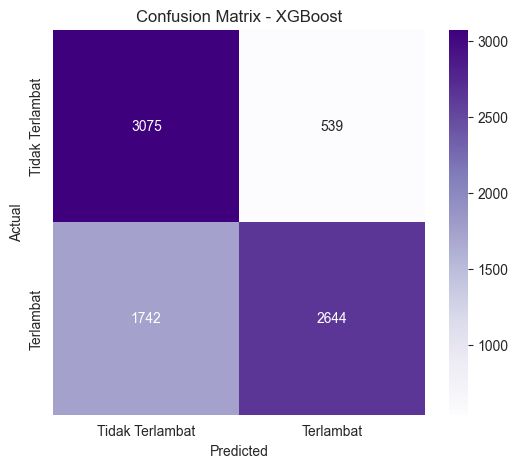

In [145]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Tidak Terlambat', 'Terlambat'],
    yticklabels=['Tidak Terlambat', 'Terlambat']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [146]:
train_pred = xgb.predict(X_train)

train_acc = accuracy_score(y_train, train_pred) * 100
test_acc = accuracy_score(y_test, y_pred_xgb) * 100

print(f"Training Accuracy : {train_acc:.2f}%")
print(f"Testing Accuracy  : {test_acc:.2f}%")
print(f"Gap               : {train_acc - test_acc:.2f}%")

Training Accuracy : 76.34%
Testing Accuracy  : 71.49%
Gap               : 4.85%


## PERBANDINGAN METRIK: BASELINE VS HYPERPARAMETER TUNING (5 METRIK) 

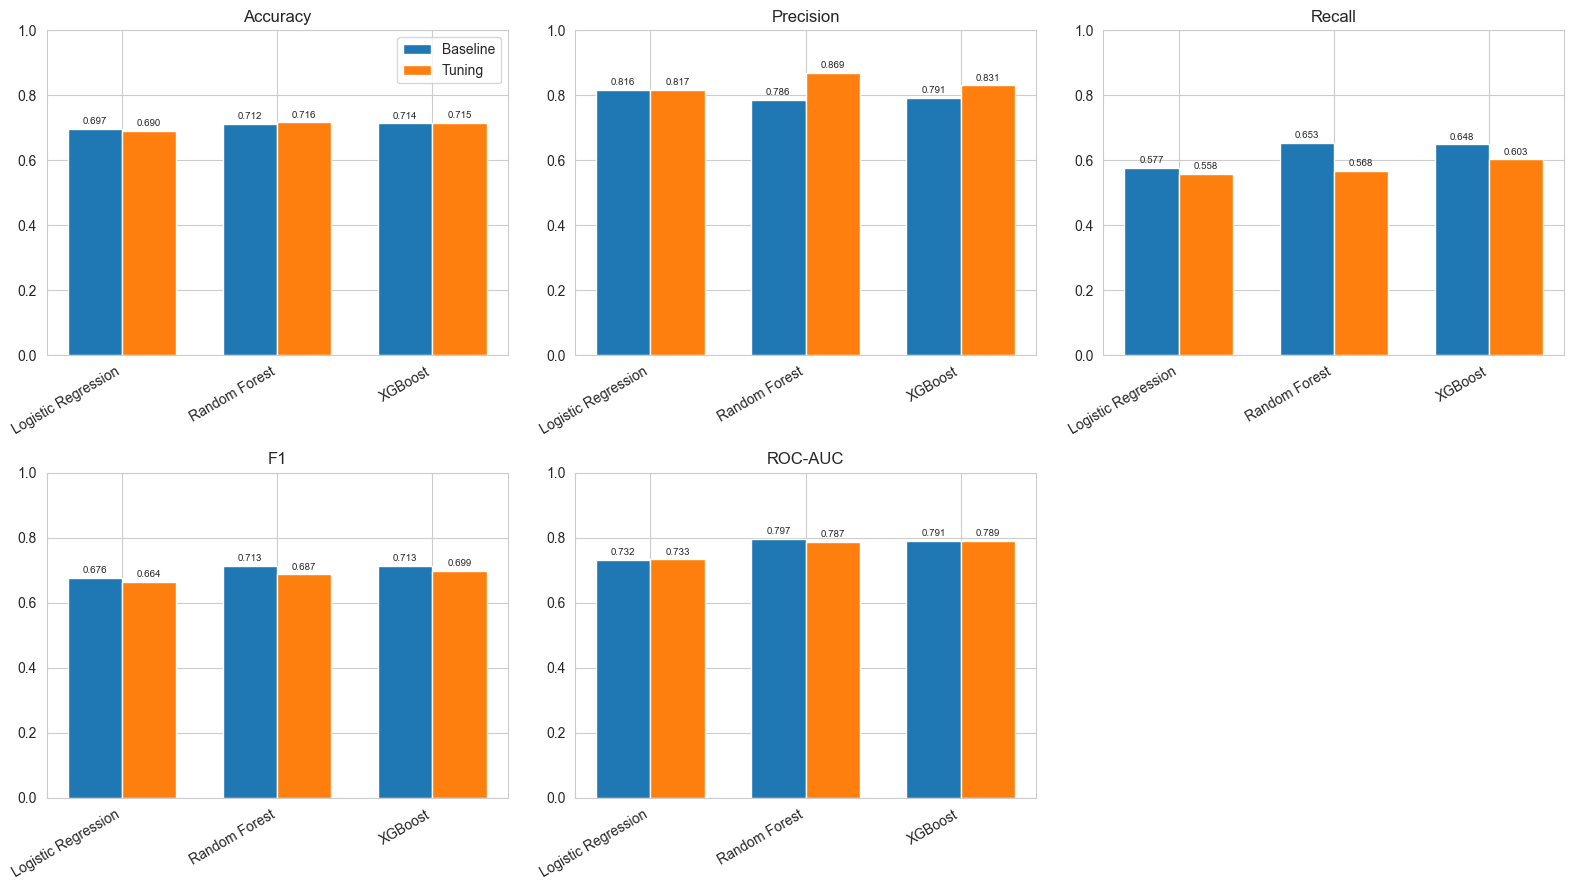

In [147]:
# ======================================================================
# PERBANDINGAN METRIK: BASELINE VS HYPERPARAMETER TUNING (5 METRIK)
# ======================================================================

algo_names = ['Logistic Regression', 'Random Forest', 'XGBoost']

# Prediksi & probabilitas baseline
preds_base  = [y_pred_lr_base, y_pred_rf_base, y_pred_xgb_base]
probs_base  = [y_prob_lr_base, y_prob_rf_base, y_prob_xgb_base]

# Prediksi & probabilitas hasil tuning
preds_tuned = [y_pred_lr, y_pred_rf, y_pred_xgb]
probs_tuned = [y_prob_lr, y_prob_rf, y_prob_xgb]

metrics = {
    'Accuracy':  lambda y_true, y_pred, y_prob: accuracy_score(y_true, y_pred),
    'Precision': lambda y_true, y_pred, y_prob: precision_score(y_true, y_pred),
    'Recall':    lambda y_true, y_pred, y_prob: recall_score(y_true, y_pred),
    'F1':        lambda y_true, y_pred, y_prob: f1_score(y_true, y_pred),
    'ROC-AUC':   lambda y_true, y_pred, y_prob: roc_auc_score(y_true, y_prob),
}

# Hitung tiap metrik untuk baseline & tuning, per algoritma
results = {}
for metric_name, func in metrics.items():
    base_vals  = [func(y_test, p, pr) for p, pr in zip(preds_base, probs_base)]
    tuned_vals = [func(y_test, p, pr) for p, pr in zip(preds_tuned, probs_tuned)]
    results[metric_name] = {'Baseline': base_vals, 'Tuning': tuned_vals}

# Plot 5 subplot (2 baris x 3 kolom, 1 slot kosong)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

x = np.arange(len(algo_names))
width = 0.35

for i, metric_name in enumerate(metrics.keys()):
    ax = axes[i]
    base_vals  = results[metric_name]['Baseline']
    tuned_vals = results[metric_name]['Tuning']

    bars1 = ax.bar(x - width/2, base_vals, width, label='Baseline', color='#1f77b4')
    bars2 = ax.bar(x + width/2, tuned_vals, width, label='Tuning', color='#ff7f0e')

    ax.set_title(metric_name)
    ax.set_ylim(0, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(algo_names, rotation=30, ha='right')

    # label angka di atas tiap bar
    for bars in (bars1, bars2):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 2), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)

    if i == 0:
        ax.legend()

# Kosongkan subplot ke-6 (karena cuma 5 metrik)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [148]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

hasil = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],

    'Accuracy Baseline': [
        accuracy_score(y_test, y_pred_lr_base),
        accuracy_score(y_test, y_pred_rf_base),
        accuracy_score(y_test, y_pred_xgb_base)
    ],

    'Accuracy Tuning': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision Baseline': [
        precision_score(y_test, y_pred_lr_base),
        precision_score(y_test, y_pred_rf_base),
        precision_score(y_test, y_pred_xgb_base)
    ],

    'Precision Tuning': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall Baseline': [
        recall_score(y_test, y_pred_lr_base),
        recall_score(y_test, y_pred_rf_base),
        recall_score(y_test, y_pred_xgb_base)
    ],

    'Recall Tuning': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1 Baseline': [
        f1_score(y_test, y_pred_lr_base),
        f1_score(y_test, y_pred_rf_base),
        f1_score(y_test, y_pred_xgb_base)
    ],

    'F1 Tuning': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    'ROC-AUC Baseline': [
        roc_auc_score(y_test, y_prob_lr_base),
        roc_auc_score(y_test, y_prob_rf_base),
        roc_auc_score(y_test, y_prob_xgb_base)
    ],

    'ROC-AUC Tuning': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

hasil = hasil.round(4)

print(hasil)

                 Model  Accuracy Baseline  Accuracy Tuning  \
0  Logistic Regression             0.6968           0.6895   
1        Random Forest             0.7124           0.7163   
2              XGBoost             0.7135           0.7149   

   Precision Baseline  Precision Tuning  Recall Baseline  Recall Tuning  \
0              0.8161            0.8174           0.5768         0.5584   
1              0.7863            0.8692           0.6528         0.5679   
2              0.7913            0.8307           0.6484         0.6028   

   F1 Baseline  F1 Tuning  ROC-AUC Baseline  ROC-AUC Tuning  
0       0.6759     0.6635            0.7324          0.7335  
1       0.7133     0.6870            0.7970          0.7869  
2       0.7128     0.6986            0.7909          0.7892  


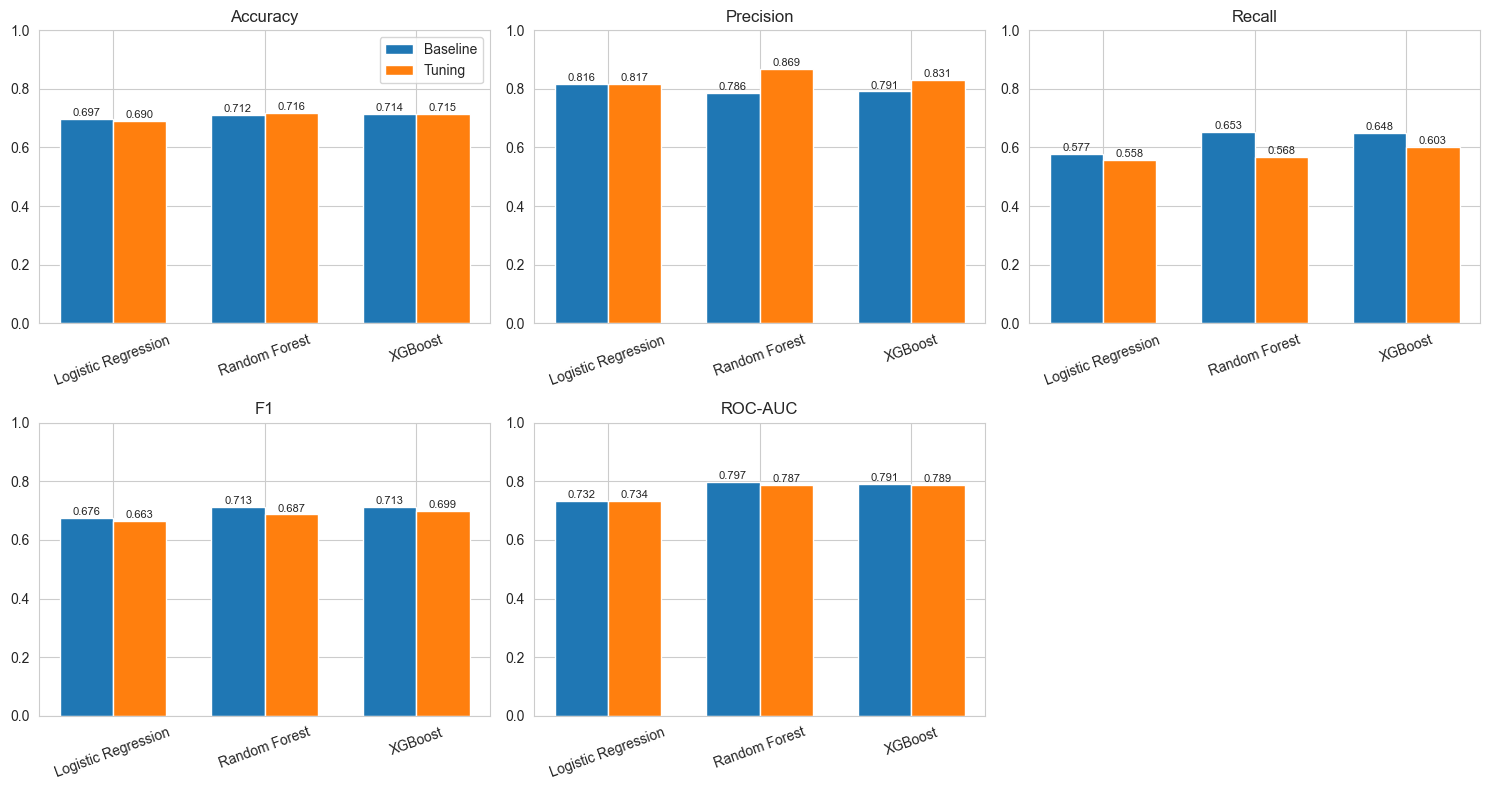

In [149]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    baseline = hasil[f'{metric} Baseline']
    tuning = hasil[f'{metric} Tuning']

    x = np.arange(len(hasil))
    width = 0.35

    axes[i].bar(x-width/2, baseline, width, label='Baseline')
    axes[i].bar(x+width/2, tuning, width, label='Tuning')

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(hasil['Model'], rotation=20)
    axes[i].set_title(metric)
    axes[i].set_ylim(0,1)

    for j,v in enumerate(baseline):
        axes[i].text(j-width/2, v+0.01, f'{v:.3f}', ha='center', fontsize=8)

    for j,v in enumerate(tuning):
        axes[i].text(j+width/2, v+0.01, f'{v:.3f}', ha='center', fontsize=8)

axes[0].legend()
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## FEATURE IMPORTANCE DR KETIGA ALGORITMA

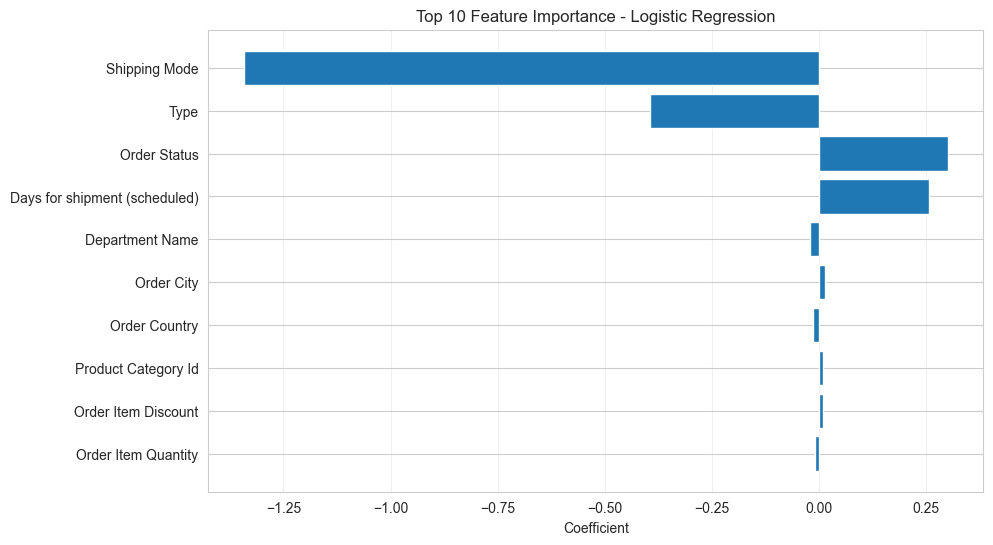

In [150]:
coef = lr.coef_[0]


feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coef
})

feature_importance_lr['Absolute'] = feature_importance_lr['Coefficient'].abs()

#diurutinn pengaruh terbesar ke terkecil
feature_importance_lr = feature_importance_lr.sort_values(
    by='Absolute',
    ascending=False
)


plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_lr['Feature'][:10],
    feature_importance_lr['Coefficient'][:10]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance - Logistic Regression")
plt.xlabel("Coefficient")
plt.grid(axis='x', alpha=0.3)
plt.show()

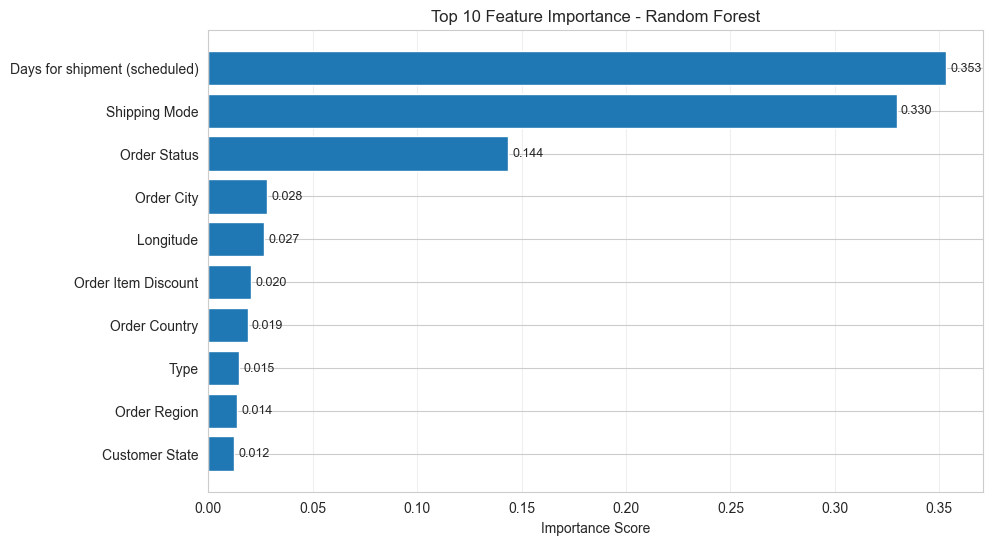

In [151]:
importance_rf = rf.feature_importances_


feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance_rf
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

top10 = feature_importance_rf.head(10)

# Plot
plt.figure(figsize=(10,6))
bars = plt.barh(top10['Feature'], top10['Importance'])

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.3f}',
        va='center',
        fontsize=9
    )

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.grid(axis='x', alpha=0.3)
plt.show()

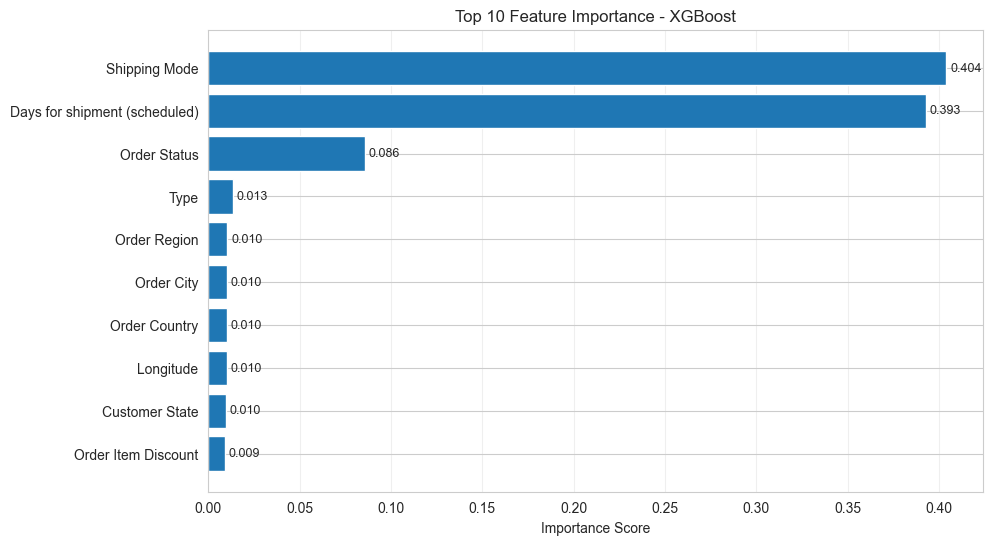

In [152]:
# Mengambil feature importance
importance_xgb = xgb.feature_importances_

feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance_xgb
})

# Urutkan dari terbesar
feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

top10 = feature_importance_xgb.head(10)
plt.figure(figsize=(10,6))
bars = plt.barh(top10['Feature'], top10['Importance'])

plt.gca().invert_yaxis()


for bar in bars:
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.3f}',
        va='center',
        fontsize=9
    )

plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.grid(axis='x', alpha=0.3)
plt.show()

## ROC-AUC CURVE & PRECISON-RECALL CURVE

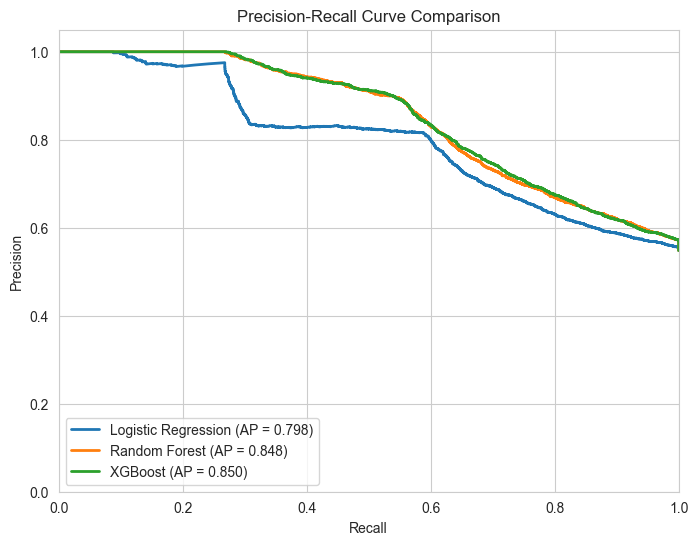

In [153]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
ap_xgb = average_precision_score(y_test, y_prob_xgb)


plt.figure(figsize=(8,6))
plt.plot(
    recall_lr,
    precision_lr,
    label=f'Logistic Regression (AP = {ap_lr:.3f})',
    linewidth=2
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f'Random Forest (AP = {ap_rf:.3f})',
    linewidth=2
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f'XGBoost (AP = {ap_xgb:.3f})',
    linewidth=2
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.legend(loc='lower left')
plt.grid(True)

plt.show()

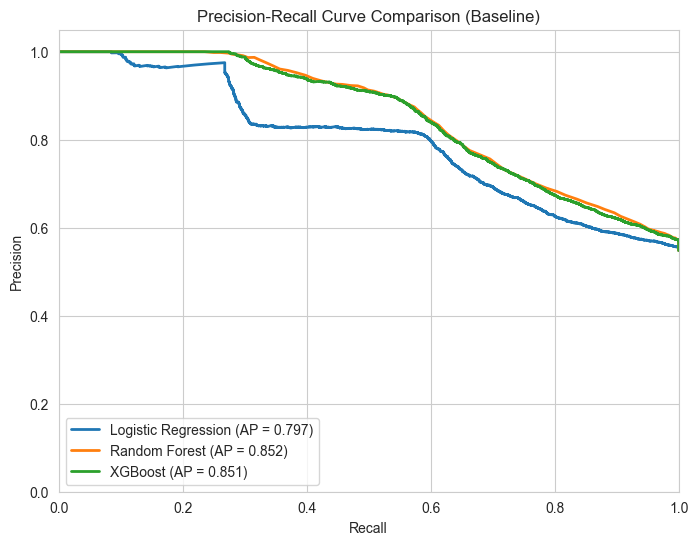

In [154]:
# BASE MODEL

# Logistic Regression
precision_lr_base, recall_lr_base, _ = precision_recall_curve(
    y_test, y_prob_lr_base
)
ap_lr_base = average_precision_score(y_test, y_prob_lr_base)

# Random Forest
precision_rf_base, recall_rf_base, _ = precision_recall_curve(
    y_test, y_prob_rf_base
)
ap_rf_base = average_precision_score(y_test, y_prob_rf_base)

# XGBoost
precision_xgb_base, recall_xgb_base, _ = precision_recall_curve(
    y_test, y_prob_xgb_base
)
ap_xgb_base = average_precision_score(y_test, y_prob_xgb_base)


plt.figure(figsize=(8,6))

plt.plot(
    recall_lr_base,
    precision_lr_base,
    label=f'Logistic Regression (AP = {ap_lr_base:.3f})',
    linewidth=2
)

plt.plot(
    recall_rf_base,
    precision_rf_base,
    label=f'Random Forest (AP = {ap_rf_base:.3f})',
    linewidth=2
)

plt.plot(
    recall_xgb_base,
    precision_xgb_base,
    label=f'XGBoost (AP = {ap_xgb_base:.3f})',
    linewidth=2
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison (Baseline)')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

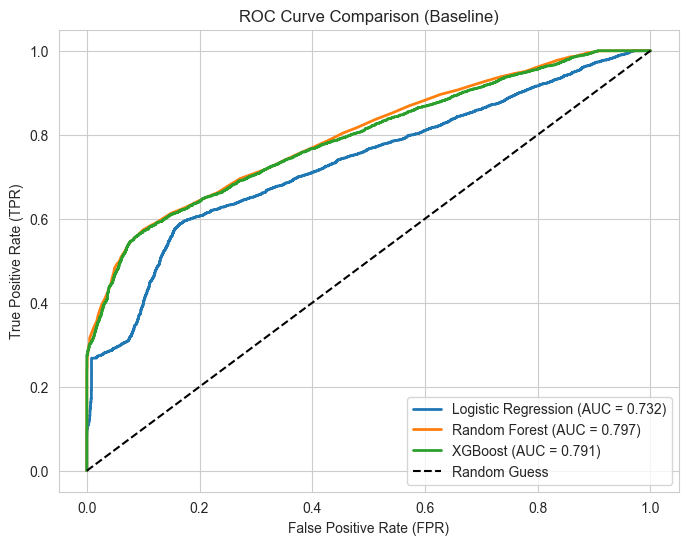

In [155]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Dictionary model baseline
models = {
    "Logistic Regression": (lr_base, X_test_scaled),
    "Random Forest": (rf_base, X_test),
    "XGBoost": (xgb_base, X_test)
}

plt.figure(figsize=(8,6))

for name, (model, X) in models.items():

    y_prob = model.predict_proba(X)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {auc:.3f})'
    )

# Garis acuan
plt.plot([0,1],[0,1],'k--',label='Random Guess')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison (Baseline)')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

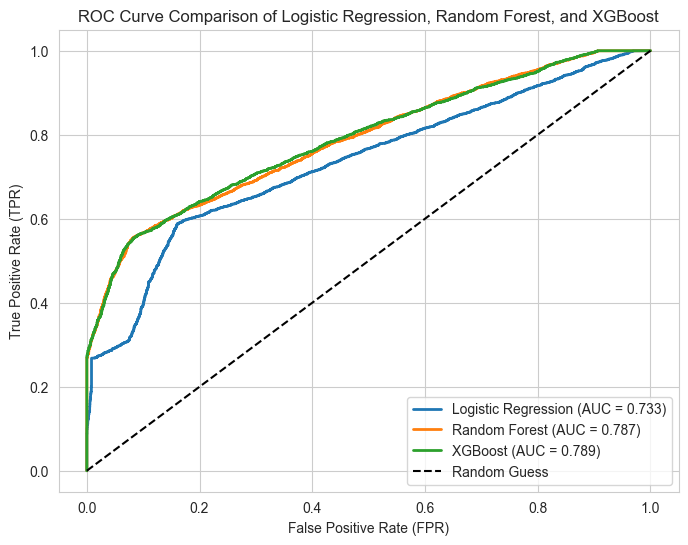

In [156]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Dictionary model
models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Random Forest": (rf, X_test),
    "XGBoost": (xgb, X_test)
}

plt.figure(figsize=(8,6))

for name, (model, X) in models.items():

    # Prediksi
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {auc:.3f})'
    )

# Garis acak
plt.plot([0,1],[0,1],'k--',label='Random Guess')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison of Logistic Regression, Random Forest, and XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

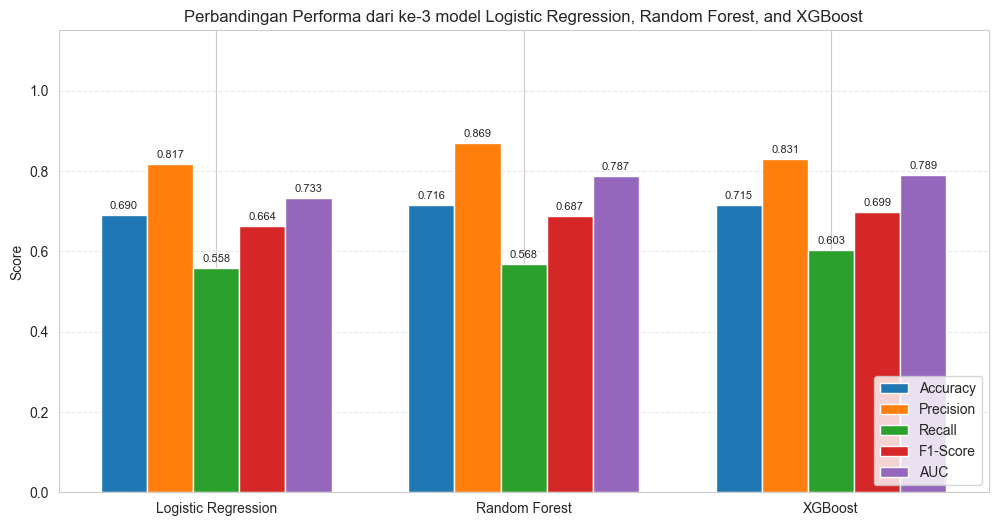

In [157]:
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
models = ['Logistic Regression', 'Random Forest', 'XGBoost']

# Prediksi
predictions = [y_pred_lr, y_pred_rf, y_pred_xgb]

# Hitung metrik
accuracy = [accuracy_score(y_test, y) for y in predictions]
precision = [precision_score(y_test, y, zero_division=0) for y in predictions]
recall = [recall_score(y_test, y, zero_division=0) for y in predictions]
f1 = [f1_score(y_test, y, zero_division=0) for y in predictions]
auc = [auc_lr, auc_rf, auc_xgb]

# Plot
x = np.arange(len(models))
width = 0.15

plt.figure(figsize=(12,6))

bars1 = plt.bar(x-2*width, accuracy, width, label='Accuracy')
bars2 = plt.bar(x-width, precision, width, label='Precision')
bars3 = plt.bar(x, recall, width, label='Recall')
bars4 = plt.bar(x+width, f1, width, label='F1-Score')
bars5 = plt.bar(x+2*width, auc, width, label='AUC')

# Tambahkan nilai di atas setiap batang
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(x, models)
plt.ylim(0, 1.15)
plt.ylabel('Score')
plt.title('Perbandingan Performa dari ke-3 model Logistic Regression, Random Forest, and XGBoost')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

## LEARNING CURVE KE-3 ALGORITMA

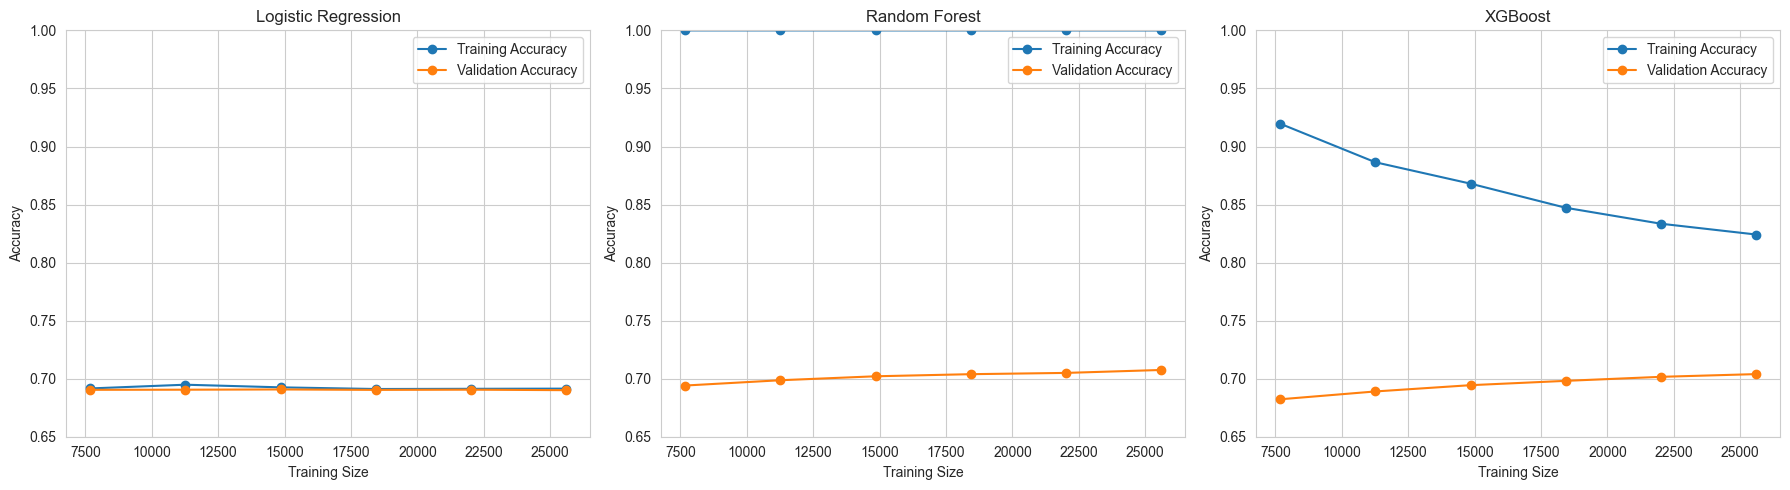

In [158]:
#BASELINE
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [
    ("Logistic Regression", lr_base, X_train_scaled),
    ("Random Forest", rf_base, X_train),
    ("XGBoost", xgb_base, X_train)
]

for ax, (name, model, X_data) in zip(axes, models):

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_data,
        y=y_train,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.3, 1.0, 6),
        shuffle=True,
        random_state=42,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
    ax.plot(train_sizes, val_mean, marker='o', label='Validation Accuracy')

    ax.set_title(name)
    ax.set_xlabel("Training Size")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.65, 1.00)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

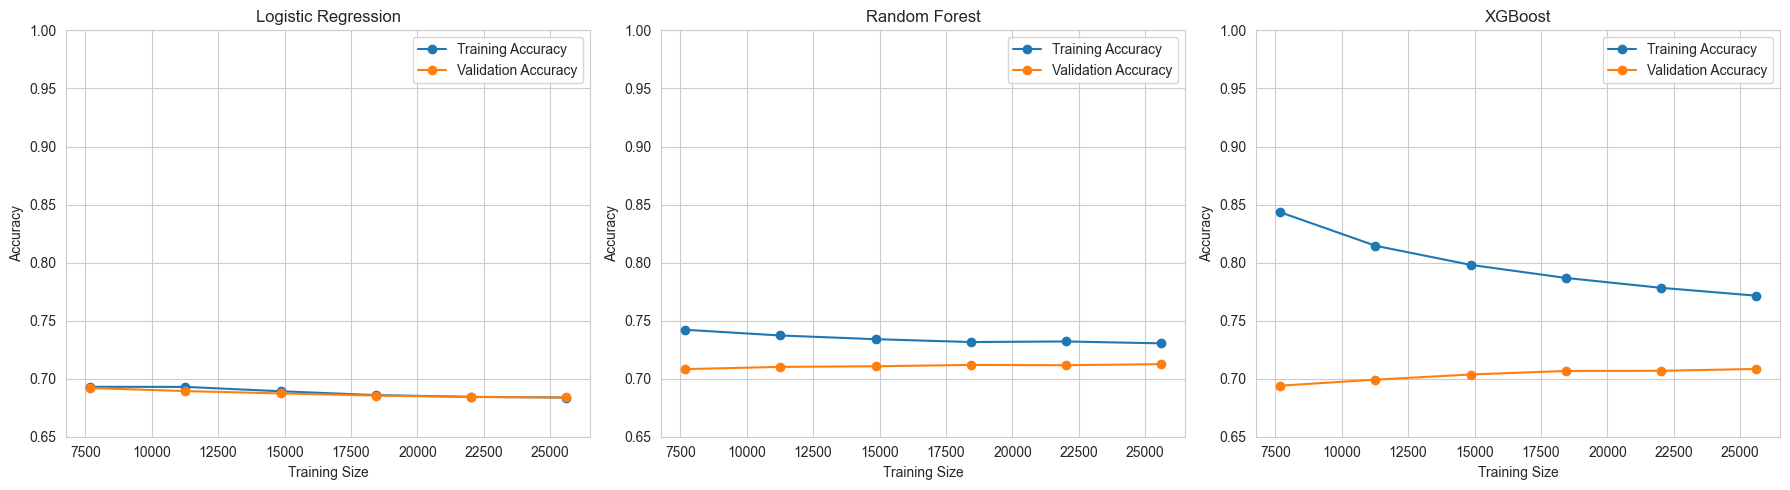

In [159]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [
    ("Logistic Regression", lr, X_train_scaled),
    ("Random Forest", rf, X_train),
    ("XGBoost", xgb, X_train)
]

for ax, (name, model, X_data) in zip(axes, models):

    train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X_data,
    y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.3, 1.0, 6),
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
    ax.plot(train_sizes, val_mean, marker='o', label='Validation Accuracy')

    ax.set_title(name)
    ax.set_xlabel("Training Size")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.65, 1.00)  
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## CROSS VALIDATION 

In [160]:
#BASELINE

from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_summary = []
for name, model, X_data in [
    ("Logistic Regression", lr_base, X_train_scaled),
    ("Random Forest", rf_base, X_train),
    ("XGBoost", xgb_base, X_train)
]:
    scores = cross_val_score(model, X_data, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_summary.append({'Model': name, 'ROC-AUC Mean': scores.mean(), 'ROC-AUC Std': scores.std()})
    print(f"{name:22s} | ROC-AUC CV: {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df

Logistic Regression    | ROC-AUC CV: 0.7275 (+/- 0.0044)
Random Forest          | ROC-AUC CV: 0.7868 (+/- 0.0050)
XGBoost                | ROC-AUC CV: 0.7827 (+/- 0.0043)


,Model,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.727536,0.004415
1,Random Forest,0.786848,0.005016
2,XGBoost,0.782737,0.004307


In [161]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_summary = []
for name, model, X_data in [
    ("Logistic Regression", lr, X_train_scaled),
    ("Random Forest", rf, X_train),
    ("XGBoost", xgb, X_train)
]:
    scores = cross_val_score(model, X_data, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_summary.append({'Model': name, 'ROC-AUC Mean': scores.mean(), 'ROC-AUC Std': scores.std()})
    print(f"{name:22s} | ROC-AUC CV: {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df

Logistic Regression    | ROC-AUC CV: 0.7285 (+/- 0.0046)
Random Forest          | ROC-AUC CV: 0.7783 (+/- 0.0047)
XGBoost                | ROC-AUC CV: 0.7824 (+/- 0.0046)


,Model,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.728545,0.004574
1,Random Forest,0.778345,0.004743
2,XGBoost,0.782407,0.004640


## VALIDATION CURVE

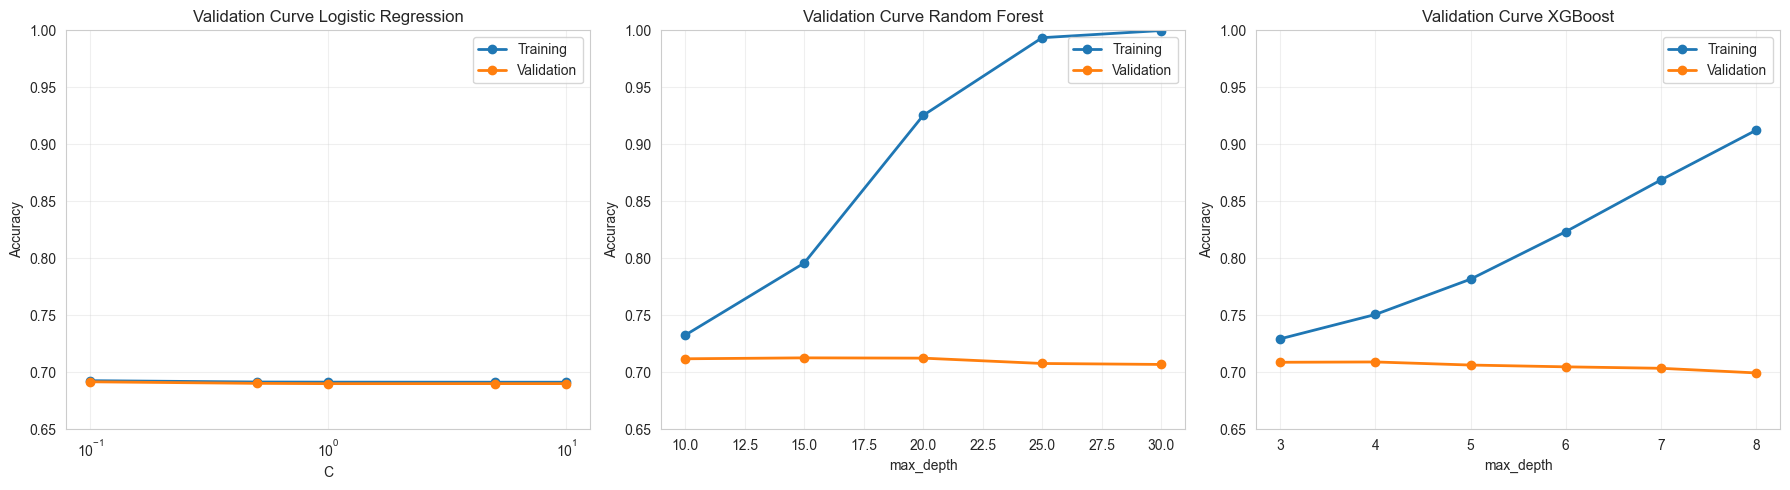

In [162]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ================= Logistic Regression =================
param_range_lr = [0.1, 0.5, 1, 5, 10]

train_scores, val_scores = validation_curve(
    estimator=lr_base,
    X=X_train_scaled,
    y=y_train,
    param_name="C",
    param_range=param_range_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

axes[0].plot(param_range_lr, train_scores.mean(axis=1),
             marker='o', linewidth=2, label='Training')

axes[0].plot(param_range_lr, val_scores.mean(axis=1),
             marker='o', linewidth=2, label='Validation')

axes[0].set_xscale("log")
axes[0].set_title("Validation Curve Logistic Regression")
axes[0].set_xlabel("C")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ================= Random Forest =================
param_range_rf = [10, 15, 20, 25, 30]

train_scores, val_scores = validation_curve(
    estimator=rf_base,
    X=X_train,
    y=y_train,
    param_name="max_depth",
    param_range=param_range_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

axes[1].plot(param_range_rf, train_scores.mean(axis=1),
             marker='o', linewidth=2, label='Training')

axes[1].plot(param_range_rf, val_scores.mean(axis=1),
             marker='o', linewidth=2, label='Validation')

axes[1].set_title("Validation Curve Random Forest")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ================= XGBoost =================
param_range_xgb = [3, 4, 5, 6, 7, 8]

train_scores, val_scores = validation_curve(
    estimator=xgb_base,
    X=X_train,
    y=y_train,
    param_name="max_depth",
    param_range=param_range_xgb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

axes[2].plot(param_range_xgb, train_scores.mean(axis=1),
             marker='o', linewidth=2, label='Training')

axes[2].plot(param_range_xgb, val_scores.mean(axis=1),
             marker='o', linewidth=2, label='Validation')

axes[2].set_title("Validation Curve XGBoost")
axes[2].set_xlabel("max_depth")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_ylim(0.65, 1.00)

plt.tight_layout()
plt.show()

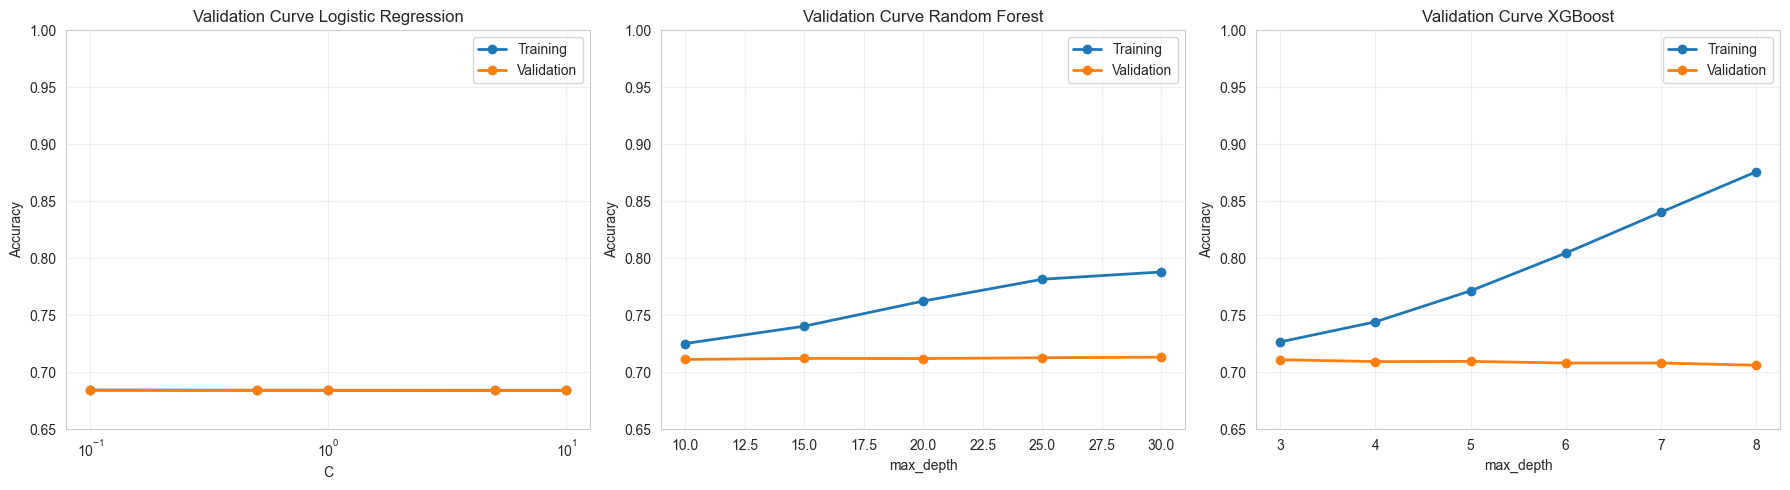

In [163]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Logistic Regression (Parameter C)
param_range_lr = [0.1, 0.5, 1, 5, 10]

train_scores, val_scores = validation_curve(
    estimator=lr,
    X=X_train_scaled,
    y=y_train,
    param_name="C",
    param_range=param_range_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

axes[0].plot(param_range_lr, train_scores.mean(axis=1),
             marker='o', linewidth=2, label='Training')

axes[0].plot(param_range_lr, val_scores.mean(axis=1),
             marker='o', linewidth=2, label='Validation')

axes[0].set_xscale("log")
axes[0].set_title("Validation Curve Logistic Regression")
axes[0].set_xlabel("C")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)


# Random Forest (Parameter max_depth)
param_range_rf = [10, 15, 20, 25, 30]

train_scores, val_scores = validation_curve(
    estimator=rf,
    X=X_train,
    y=y_train,
    param_name="max_depth",
    param_range=param_range_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

axes[1].plot(param_range_rf, train_scores.mean(axis=1),
             marker='o', linewidth=2, label='Training')

axes[1].plot(param_range_rf, val_scores.mean(axis=1),
             marker='o', linewidth=2, label='Validation')

axes[1].set_title("Validation Curve Random Forest")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)


# XGBoost (Parameter max_depth)
param_range_xgb = [3, 4, 5, 6, 7, 8]

train_scores, val_scores = validation_curve(
    estimator=xgb,
    X=X_train,
    y=y_train,
    param_name="max_depth",
    param_range=param_range_xgb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

axes[2].plot(param_range_xgb, train_scores.mean(axis=1),
             marker='o', linewidth=2, label='Training')

axes[2].plot(param_range_xgb, val_scores.mean(axis=1),
             marker='o', linewidth=2, label='Validation')

axes[2].set_title("Validation Curve XGBoost")
axes[2].set_xlabel("max_depth")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(alpha=0.3)


for ax in axes:
    ax.set_ylim(0.65, 1.00)

plt.tight_layout()
plt.show()

### Data Balancing (SMOTE)

In [164]:
# BASELINE + SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Distribusi kelas sebelum SMOTE:", dict(y_train.value_counts()))
print("Distribusi kelas setelah SMOTE :", dict(pd.Series(y_train_sm).value_counts()))

# Baseline
lr_balanced_base = LogisticRegression(random_state=42, max_iter=1000)
lr_balanced_base.fit(X_train_sm, y_train_sm)
y_pred_lr_bal_base = lr_balanced_base.predict(X_test_scaled)

print("\nAccuracy Logistic Regression Baseline + SMOTE:",
      accuracy_score(y_test, y_pred_lr_bal_base))
print(classification_report(y_test, y_pred_lr_bal_base))

Distribusi kelas sebelum SMOTE: {1: np.int64(17546), 0: np.int64(14454)}
Distribusi kelas setelah SMOTE : {0: np.int64(17546), 1: np.int64(17546)}

Accuracy Logistic Regression Baseline + SMOTE: 0.690375
              precision    recall  f1-score   support

           0       0.61      0.85      0.71      3614
           1       0.82      0.56      0.66      4386

    accuracy                           0.69      8000
   macro avg       0.72      0.70      0.69      8000
weighted avg       0.73      0.69      0.69      8000



In [165]:
lr_balanced_tuned = LogisticRegression(
    **grid_lr.best_params_,
    random_state=42,
    max_iter=1000
)
lr_balanced_tuned.fit(X_train_sm, y_train_sm)
y_pred_lr_bal_tuned = lr_balanced_tuned.predict(X_test_scaled)

print("\nAccuracy Logistic Regression Tuning + SMOTE:",
      accuracy_score(y_test, y_pred_lr_bal_tuned))
print(classification_report(y_test, y_pred_lr_bal_tuned))


Accuracy Logistic Regression Tuning + SMOTE: 0.689625
              precision    recall  f1-score   support

           0       0.61      0.85      0.71      3614
           1       0.82      0.56      0.66      4386

    accuracy                           0.69      8000
   macro avg       0.72      0.70      0.69      8000
weighted avg       0.73      0.69      0.69      8000



In [166]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Distribusi kelas sebelum SMOTE:", dict(y_train.value_counts()))
print("Distribusi kelas setelah SMOTE :", dict(pd.Series(y_train_sm).value_counts()))

# Baseline
xgb_balanced_base = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_balanced_base.fit(X_train_sm, y_train_sm)
y_pred_xgb_bal_base = xgb_balanced_base.predict(X_test)

print("\nAccuracy XGBoost Baseline + SMOTE:",
      accuracy_score(y_test, y_pred_xgb_bal_base))
print(classification_report(y_test, y_pred_xgb_bal_base))

Distribusi kelas sebelum SMOTE: {1: np.int64(17546), 0: np.int64(14454)}
Distribusi kelas setelah SMOTE : {0: np.int64(17546), 1: np.int64(17546)}

Accuracy XGBoost Baseline + SMOTE: 0.714375
              precision    recall  f1-score   support

           0       0.65      0.81      0.72      3614
           1       0.80      0.63      0.71      4386

    accuracy                           0.71      8000
   macro avg       0.72      0.72      0.71      8000
weighted avg       0.73      0.71      0.71      8000



In [167]:
from imblearn.over_sampling import SMOTE

xgb_balanced_tuned = XGBClassifier(
    **random_xgb.best_params_,
    random_state=42,
    eval_metric='logloss'
)
xgb_balanced_tuned.fit(X_train_sm, y_train_sm)
y_pred_xgb_bal_tuned = xgb_balanced_tuned.predict(X_test)

print("\nAccuracy XGBoost Tuning + SMOTE:",
      accuracy_score(y_test, y_pred_xgb_bal_tuned))
print(classification_report(y_test, y_pred_xgb_bal_tuned))


Accuracy XGBoost Tuning + SMOTE: 0.716625
              precision    recall  f1-score   support

           0       0.64      0.88      0.74      3614
           1       0.85      0.59      0.69      4386

    accuracy                           0.72      8000
   macro avg       0.74      0.73      0.72      8000
weighted avg       0.75      0.72      0.71      8000



In [168]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Distribusi kelas sebelum SMOTE:", dict(y_train.value_counts()))
print("Distribusi kelas setelah SMOTE :", dict(pd.Series(y_train_sm).value_counts()))

# Baseline
rf_balanced_base = RandomForestClassifier(random_state=42)
rf_balanced_base.fit(X_train_sm, y_train_sm)
y_pred_rf_bal_base = rf_balanced_base.predict(X_test)

print("\nAccuracy Random Forest Baseline + SMOTE:",
      accuracy_score(y_test, y_pred_rf_bal_base))
print(classification_report(y_test, y_pred_rf_bal_base))

Distribusi kelas sebelum SMOTE: {1: np.int64(17546), 0: np.int64(14454)}
Distribusi kelas setelah SMOTE : {0: np.int64(17546), 1: np.int64(17546)}

Accuracy Random Forest Baseline + SMOTE: 0.71925
              precision    recall  f1-score   support

           0       0.65      0.82      0.73      3614
           1       0.81      0.64      0.71      4386

    accuracy                           0.72      8000
   macro avg       0.73      0.73      0.72      8000
weighted avg       0.74      0.72      0.72      8000



In [169]:
rf_balanced_tuned = RandomForestClassifier(
    **random_rf.best_params_,
    random_state=42
)
rf_balanced_tuned.fit(X_train_sm, y_train_sm)
y_pred_rf_bal_tuned = rf_balanced_tuned.predict(X_test)

print("\nAccuracy Random Forest Tuning + SMOTE:",
      accuracy_score(y_test, y_pred_rf_bal_tuned))
print(classification_report(y_test, y_pred_rf_bal_tuned))


Accuracy Random Forest Tuning + SMOTE: 0.718875
              precision    recall  f1-score   support

           0       0.63      0.91      0.75      3614
           1       0.88      0.56      0.69      4386

    accuracy                           0.72      8000
   macro avg       0.76      0.74      0.72      8000
weighted avg       0.77      0.72      0.71      8000



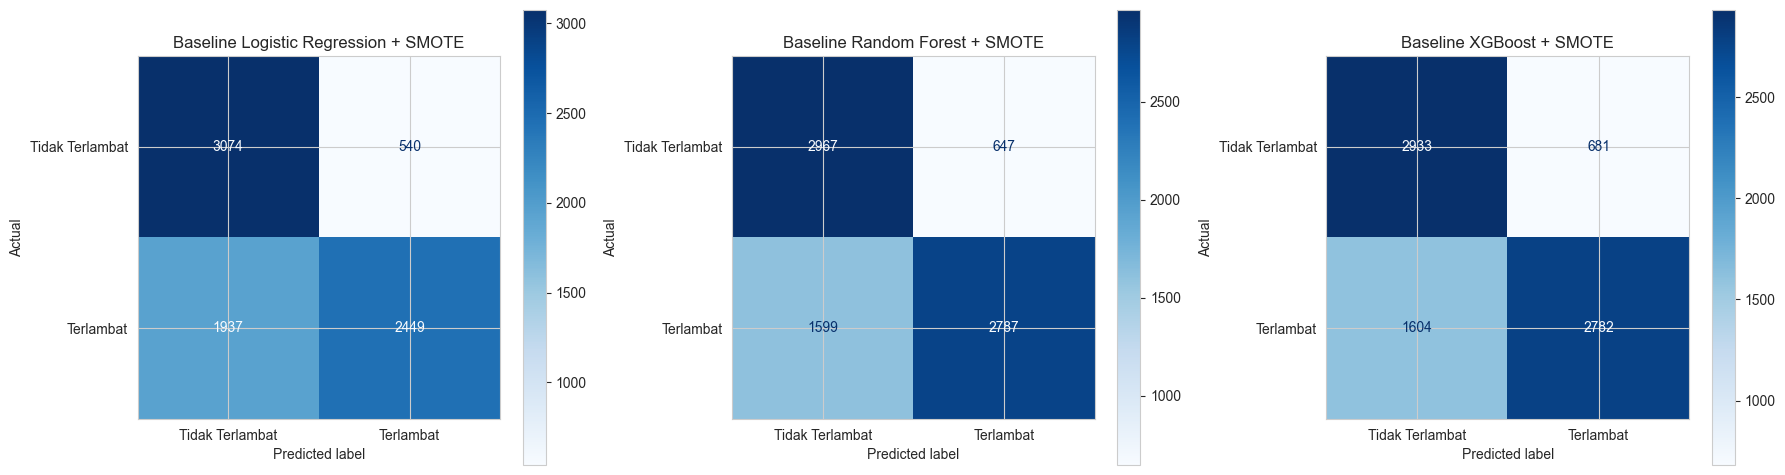

In [170]:
# ---------------- Confusion Matrix: Baseline + SMOTE (ketiga algoritma) ----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Tidak Terlambat", "Terlambat"]

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_bal_base, display_labels=labels, cmap="Blues", ax=axes[0]
)
axes[0].set_title("Baseline Logistic Regression + SMOTE")
axes[0].set_ylabel("Actual")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_bal_base, display_labels=labels, cmap="Blues", ax=axes[1]
)
axes[1].set_title("Baseline Random Forest + SMOTE")
axes[1].set_ylabel("Actual")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_bal_base, display_labels=labels, cmap="Blues", ax=axes[2]
)
axes[2].set_title("Baseline XGBoost + SMOTE")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

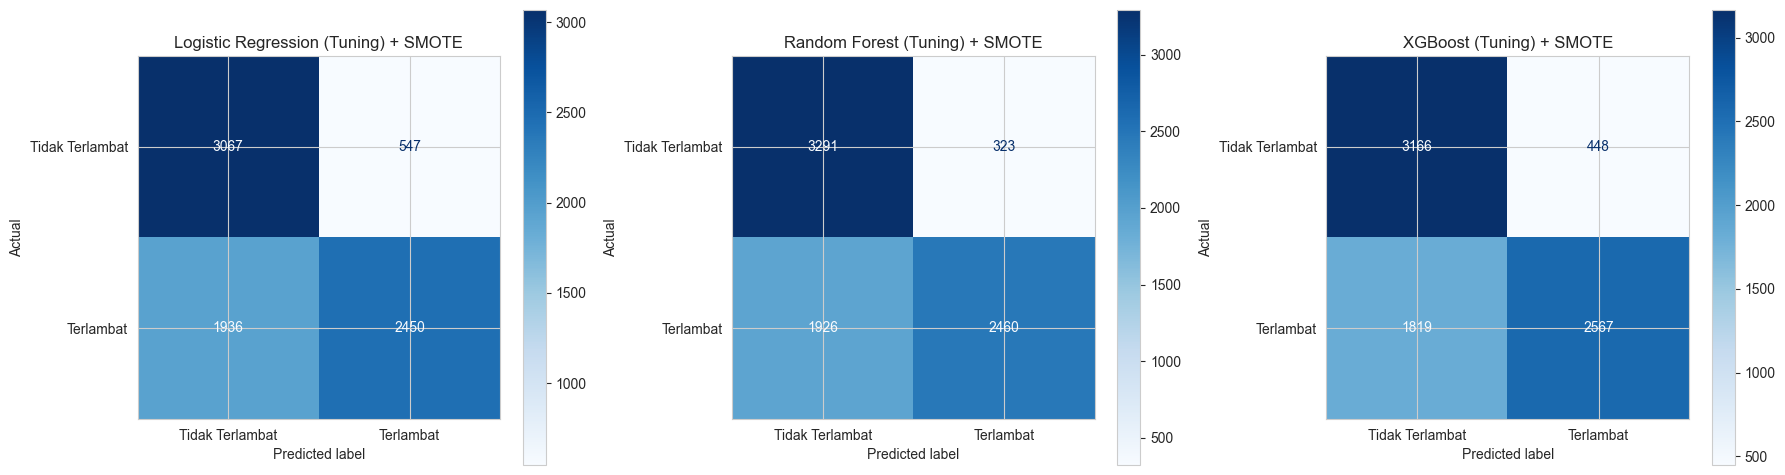

In [171]:
# ---------------- Confusion Matrix: Tuning + SMOTE (ketiga algoritma) ----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_bal_tuned, display_labels=labels, cmap="Blues", ax=axes[0]
)
axes[0].set_title("Logistic Regression (Tuning) + SMOTE")
axes[0].set_ylabel("Actual")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_bal_tuned, display_labels=labels, cmap="Blues", ax=axes[1]
)
axes[1].set_title("Random Forest (Tuning) + SMOTE")
axes[1].set_ylabel("Actual")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_bal_tuned, display_labels=labels, cmap="Blues", ax=axes[2]
)
axes[2].set_title("XGBoost (Tuning) + SMOTE")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## PERBANDINGAN BASELINE VS HYPERPARAMETER TUNING TESTING&TRAINING

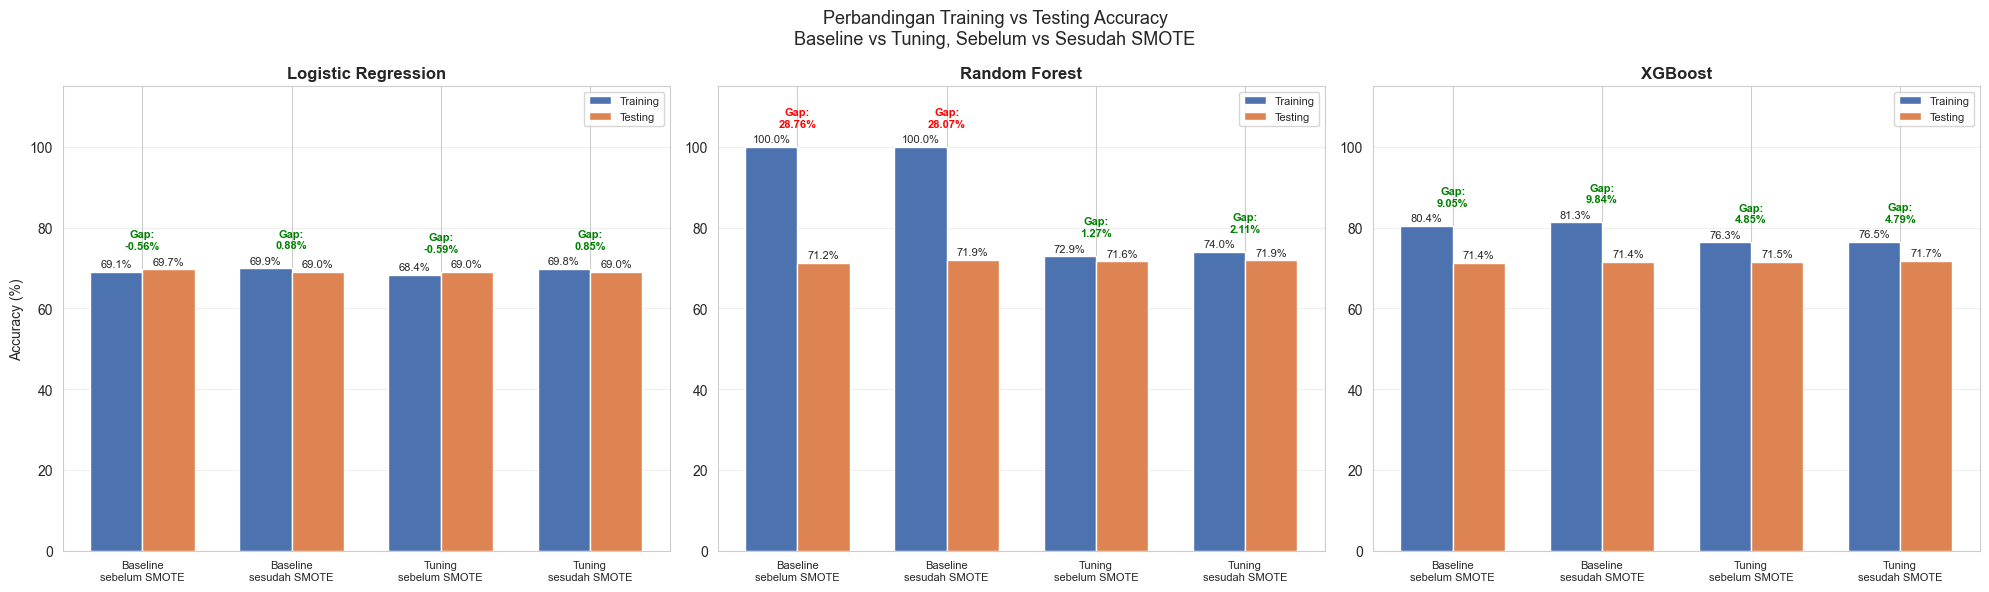

In [172]:
# ==== SMOTE resample (sekali aja, dipakai bertiga) ====
smote_plot = SMOTE(random_state=42)
X_train_sm_plot, y_train_sm_plot = smote_plot.fit_resample(X_train, y_train)

smote_plot_scaled = SMOTE(random_state=42)
X_train_sm_scaled_plot, y_train_sm_scaled_plot = smote_plot_scaled.fit_resample(X_train_scaled, y_train)

# ==== Fit ulang 4 kondisi x 3 algoritma, nama variabel baru biar aman ====

# --- Logistic Regression (pakai data scaled) ---
lr_plot_base = LogisticRegression(random_state=42, max_iter=1000)
lr_plot_base.fit(X_train_scaled, y_train)

lr_plot_base_sm = LogisticRegression(random_state=42, max_iter=1000)
lr_plot_base_sm.fit(X_train_sm_scaled_plot, y_train_sm_scaled_plot)

lr_plot_tuned = LogisticRegression(**grid_lr.best_params_, random_state=42, max_iter=1000)
lr_plot_tuned.fit(X_train_scaled, y_train)

lr_plot_tuned_sm = LogisticRegression(**grid_lr.best_params_, random_state=42, max_iter=1000)
lr_plot_tuned_sm.fit(X_train_sm_scaled_plot, y_train_sm_scaled_plot)

# --- Random Forest ---
rf_plot_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_plot_base.fit(X_train, y_train)

rf_plot_base_sm = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_plot_base_sm.fit(X_train_sm_plot, y_train_sm_plot)

rf_plot_tuned = RandomForestClassifier(**random_rf.best_params_, random_state=42, n_jobs=-1)
rf_plot_tuned.fit(X_train, y_train)

rf_plot_tuned_sm = RandomForestClassifier(**random_rf.best_params_, random_state=42, n_jobs=-1)
rf_plot_tuned_sm.fit(X_train_sm_plot, y_train_sm_plot)

# --- XGBoost ---
xgb_plot_base = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_plot_base.fit(X_train, y_train)

xgb_plot_base_sm = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_plot_base_sm.fit(X_train_sm_plot, y_train_sm_plot)

xgb_plot_tuned = XGBClassifier(**random_xgb.best_params_, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_plot_tuned.fit(X_train, y_train)

xgb_plot_tuned_sm = XGBClassifier(**random_xgb.best_params_, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_plot_tuned_sm.fit(X_train_sm_plot, y_train_sm_plot)

# ==== Kumpulkan semua hasil ====
algo_data = {
    'Logistic Regression': {
        'Baseline\nsebelum SMOTE': (lr_plot_base, X_train_scaled, y_train, X_test_scaled),
        'Baseline\nsesudah SMOTE': (lr_plot_base_sm, X_train_sm_scaled_plot, y_train_sm_scaled_plot, X_test_scaled),
        'Tuning\nsebelum SMOTE': (lr_plot_tuned, X_train_scaled, y_train, X_test_scaled),
        'Tuning\nsesudah SMOTE': (lr_plot_tuned_sm, X_train_sm_scaled_plot, y_train_sm_scaled_plot, X_test_scaled),
    },
    'Random Forest': {
        'Baseline\nsebelum SMOTE': (rf_plot_base, X_train, y_train, X_test),
        'Baseline\nsesudah SMOTE': (rf_plot_base_sm, X_train_sm_plot, y_train_sm_plot, X_test),
        'Tuning\nsebelum SMOTE': (rf_plot_tuned, X_train, y_train, X_test),
        'Tuning\nsesudah SMOTE': (rf_plot_tuned_sm, X_train_sm_plot, y_train_sm_plot, X_test),
    },
    'XGBoost': {
        'Baseline\nsebelum SMOTE': (xgb_plot_base, X_train, y_train, X_test),
        'Baseline\nsesudah SMOTE': (xgb_plot_base_sm, X_train_sm_plot, y_train_sm_plot, X_test),
        'Tuning\nsebelum SMOTE': (xgb_plot_tuned, X_train, y_train, X_test),
        'Tuning\nsesudah SMOTE': (xgb_plot_tuned_sm, X_train_sm_plot, y_train_sm_plot, X_test),
    },
}

# ==== Plot: 3 subplot berdampingan ====
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (algo_name, kondisi) in zip(axes, algo_data.items()):
    labels = list(kondisi.keys())
    train_acc, test_acc, gap = [], [], []

    for k in labels:
        model, Xtr, ytr, Xte = kondisi[k]
        tr = accuracy_score(ytr, model.predict(Xtr)) * 100
        te = accuracy_score(y_test, model.predict(Xte)) * 100
        train_acc.append(tr)
        test_acc.append(te)
        gap.append(tr - te)

    x = np.arange(len(labels))
    width = 0.35

    bars1 = ax.bar(x - width/2, train_acc, width, label='Training', color='#4C72B0')
    bars2 = ax.bar(x + width/2, test_acc, width, label='Testing', color='#DD8452')

    for bars in [bars1, bars2]:
        ax.bar_label(bars, fmt='%.1f%%', padding=2, fontsize=8)

    for i, g in enumerate(gap):
        ax.text(x[i], max(train_acc[i], test_acc[i]) + 5, f'Gap:\n{g:.2f}%',
                ha='center', fontsize=8, fontweight='bold',
                color='red' if abs(g) > 10 else 'green')

    ax.set_title(algo_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 115)
    ax.grid(axis='y', alpha=0.3)
    if ax == axes[0]:
        ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8)

fig.suptitle('Perbandingan Training vs Testing Accuracy\nBaseline vs Tuning, Sebelum vs Sesudah SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

### Ensemble (Voting Classifier)

In [173]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import make_pipeline
# Baseline Logistic Regression
lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        random_state=42,
        max_iter=1000
    )
)

# Baseline Random Forest
rf_base = RandomForestClassifier(
    random_state=42
)

# Baseline XGBoost
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Voting Classifier Baseline
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_pipeline),
        ('rf', rf_base),
        ('xgb', xgb_base)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

y_pred_voting = voting_clf.predict(X_test)
y_prob_voting = voting_clf.predict_proba(X_test)[:, 1]

print("Accuracy Voting Ensemble (Baseline):",
      accuracy_score(y_test, y_pred_voting))

print(classification_report(y_test, y_pred_voting))

Accuracy Voting Ensemble (Baseline): 0.71975
              precision    recall  f1-score   support

           0       0.65      0.84      0.73      3614
           1       0.82      0.62      0.71      4386

    accuracy                           0.72      8000
   macro avg       0.73      0.73      0.72      8000
weighted avg       0.74      0.72      0.72      8000



In [174]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import make_pipeline

lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(**grid_lr.best_params_, max_iter=1000, random_state=42)
)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_pipeline),
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)
y_prob_voting = voting_clf.predict_proba(X_test)[:, 1]

print("Accuracy Voting Ensemble:", accuracy_score(y_test, y_pred_voting))
print(classification_report(y_test, y_pred_voting))

Accuracy Voting Ensemble: 0.714375
              precision    recall  f1-score   support

           0       0.63      0.87      0.73      3614
           1       0.84      0.59      0.69      4386

    accuracy                           0.71      8000
   macro avg       0.74      0.73      0.71      8000
weighted avg       0.75      0.71      0.71      8000



In [175]:
# Baseline Random Forest
rf_base = RandomForestClassifier(
    random_state=42
)

# Baseline XGBoost
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Voting Baseline RF + XGBoost
voting_rf_xgb = VotingClassifier(
    estimators=[
        ('rf', rf_base),
        ('xgb', xgb_base)
    ],
    voting='soft'
)

# Training
voting_rf_xgb.fit(X_train, y_train)

# Prediksi
y_pred_vote = voting_rf_xgb.predict(X_test)
y_prob_vote = voting_rf_xgb.predict_proba(X_test)[:, 1]

# Evaluasi
print("Accuracy Voting (RF + XGBoost) Baseline:",
      accuracy_score(y_test, y_pred_vote))

print(classification_report(y_test, y_pred_vote))

Accuracy Voting (RF + XGBoost) Baseline: 0.71925
              precision    recall  f1-score   support

           0       0.65      0.81      0.72      3614
           1       0.81      0.64      0.72      4386

    accuracy                           0.72      8000
   macro avg       0.73      0.73      0.72      8000
weighted avg       0.74      0.72      0.72      8000



In [176]:
# Voting RF + XGBoost
voting_rf_xgb = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'
)

# Training
voting_rf_xgb.fit(X_train, y_train)

# Prediksi
y_pred_vote = voting_rf_xgb.predict(X_test)
y_prob_vote = voting_rf_xgb.predict_proba(X_test)[:, 1]

# Evaluasi
print("Accuracy Voting (RF + XGBoost):",
      accuracy_score(y_test, y_pred_vote))

print(classification_report(y_test, y_pred_vote))

Accuracy Voting (RF + XGBoost): 0.71675
              precision    recall  f1-score   support

           0       0.63      0.89      0.74      3614
           1       0.86      0.58      0.69      4386

    accuracy                           0.72      8000
   macro avg       0.75      0.73      0.71      8000
weighted avg       0.76      0.72      0.71      8000



## KESIMPULAN

In [177]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
preds = [y_pred_lr, y_pred_rf, y_pred_xgb]
probs = [y_prob_lr, y_prob_rf, y_prob_xgb]

final_summary = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    }
    for name, pred, prob in zip(model_names, preds, probs)
]).round(4).sort_values('F1-Score', ascending=False).reset_index(drop=True)

final_summary

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7149,0.8307,0.6028,0.6986,0.7892
1,Random Forest,0.7163,0.8692,0.5679,0.6870,0.7869
2,Logistic Regression,0.6895,0.8174,0.5584,0.6635,0.7335
